In [157]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text
import gget
from scipy.stats import spearmanr, kendalltau, wilcoxon
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from matplotlib import colormaps
import matplotlib.patheffects as pe

sc.settings.verbosity = 2

In [2]:
WORK_DIR = "/nfs/turbo/umms-indikar/Ram/development/projects/HardWiredGenome"

def generate_gene_id_name_map():
    ENSEMBL_GENE_NAME_PATH = f"{WORK_DIR}/data/Gene Names.tsv"

    usecols = ['Gene stable ID', 'Gene name']
    with open(ENSEMBL_GENE_NAME_PATH, 'r') as f:
        ensembl_gene_name_path = f.readlines()
    # ensembl_df = pd.read_csv(ENSEMBL_GENE_NAME_PATH, sep='\t', dtype=str, usecols=usecols, low_memory=False)

    ensmap = {}
    for row in ensembl_gene_name_path[1:]:
        splitrow = row.strip().split('\t')
        if len(splitrow) > 7:
            gene_id = splitrow[0]
            gene_name = splitrow[-1]
            ensmap[gene_id] = gene_name
                
    print(f'Extracted {len(ensmap)} mappings from {len(ensembl_gene_name_path)} ensembl lines')
        
    # gene_id_name_map = dict(zip(ensembl_df['Gene stable ID'], ensembl_df['Gene name']))
    
    gene_id_name_map_gtf = pd.read_csv(f'{WORK_DIR}/data/gene_id_name_map_gtf.csv')
    gene_id_name_map_dict = dict(zip(gene_id_name_map_gtf['gene_id'], gene_id_name_map_gtf['gene_name']))
    print(f'Extracted {len(gene_id_name_map_dict)} mappings from gene id gtf file')
    
    gene_id_name_map_dict.update(ensmap)
    
    name_id_map = {}
    for key, value in gene_id_name_map_dict.items():
        if value:
            name_id_map[value] = key

    print(f'Total Mappings Extracted {len(gene_id_name_map_dict)}')
    
    return gene_id_name_map_dict, name_id_map


DATA_DIRECTORY = '/nfs/turbo/umms-indikar/shared/projects/HWG/data/HWG/data'
HUMAN_TF_IDLIST_PATH = f"{DATA_DIRECTORY}/HTF/TFs_Ensembl_v_1.01.txt"

def get_TF_set():
    # from constants import HUMAN_TF_IDLIST_PATH
    tflist = []
    with open(HUMAN_TF_IDLIST_PATH, 'r') as f:
        for line in f.readlines():
            tflist.append(line.strip())
    print(f'processed {len(tflist)} Transcription Factors')
    return tflist 

# Function to classify based on counts
def classify_effect(group):
    counts = group["Effect"].value_counts()
    activ = counts.get("Activation", 0)
    reprs = counts.get("Repression", 0)
    unkn  = counts.get("Unknown", 0)

    if activ > reprs:
        return "Activator"
    elif reprs > activ:
        return "Repressor"
    elif activ == reprs and (activ > 0 or reprs > 0):
        return "Conflicted"
    else:
        # Let's also make unknowns as conflicted.
        return "Conflicted"

    
    
TRRUST_ACTIVITY_PATH = f"{DATA_DIRECTORY}/HTF/trrust_rawdata.human.tsv"
    
def get_TF_activity_lists(log=True):

    tflist = get_TF_set()
    gene_id_name_map, gene_name_id_map = generate_gene_id_name_map() 

    TF_activity_TRRUST = pd.read_csv(TRRUST_ACTIVITY_PATH, sep='\t', header=None,  names=["TF","Target","Effect","PMID"])

    TF_activity_TRRUST["Effect"] = TF_activity_TRRUST["Effect"].astype(str).str.strip().str.capitalize()
    classification = TF_activity_TRRUST.groupby("TF").apply(classify_effect).reset_index(name="Class")


    activators = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Activator", "TF"].tolist()]
    repressors = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Repressor", "TF"].tolist()]
    conflicted = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Conflicted", "TF"].tolist()]
    unknowns   = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Unknown", "TF"].tolist()]
    
    if log:
        print(f' Total Activators : {len(activators)}')
        print(f'Total Reprossors : {len(repressors)}')
        print(f'Total Conflicted : {len(conflicted)}')
    
        print(f'Total Transcription Factors : {len(tflist)}')
    return repressors, activators, conflicted, tflist


def binarize(mat, thresh):
    if sp.issparse(mat):
        out = mat.copy()
        out.data = (out.data > thresh).astype(np.int8)
        return out
    else:
        return (mat > thresh).astype(np.int8)
    
def get_a_matrix_threshold(threshold):
    repressorlist, activatorlist, conflictedlist, tf_list = get_TF_activity_lists()
    
    a_matrix_adata = an.read_h5ad('/nfs/turbo/umms-indikar/shared/projects/HWG/data/HWG/data/HWG/A_matrix.h5ad')
    a_matrix_adata.layers['HWG_0'] = a_matrix_adata.X
    a_bin = binarize(a_matrix_adata.layers['STRING'], threshold)
    b_bin = a_matrix_adata.layers['HURI']

    merged = a_bin + b_bin 

    if sp.issparse(merged):
        merged.data = np.ones_like(merged.data, dtype=np.int8)
    else:
        merged = (merged > 0).astype(np.int8)

    a_matrix_adata.layers[f'HWG_{threshold}'] = merged
    a_matrix_adata.X = merged

    b_matrix_true = a_matrix_adata[a_matrix_adata.obs_names.isin(tf_list)]

    c_matrix_true = a_matrix_adata[a_matrix_adata.obs_names.isin(tf_list), a_matrix_adata.var_names.isin(tf_list)]

    # c_matrix_true = a_matrix_adata[b_matrix_true.var_names.isin(tf_list)]
    
    return a_matrix_adata, b_matrix_true, c_matrix_true

# A matrix

In [3]:
# STRING score threshold 0-1000
thresh = 310

A, B, C = get_a_matrix_threshold(thresh)

print(A.shape)
print(B.shape)
print(C.shape)

processed 1639 Transcription Factors
Extracted 43945 mappings from 73467 ensembl lines
Extracted 38606 mappings from gene id gtf file
Total Mappings Extracted 59979


/tmp/ipykernel_989158/3527769353.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  classification = TF_activity_TRRUST.groupby("TF").apply(classify_effect).reset_index(name="Class")


 Total Activators : 329
Total Reprossors : 259
Total Conflicted : 207
Total Transcription Factors : 1639
(19678, 19678)
(1635, 19678)
(1635, 1635)


# Load gene info

In [4]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)
print(gtf.shape)

print(gtf.columns.tolist())

gdf = gtf[['gene_id', 'gene_name', 'Feature', 'gene_type']].copy()
gdf = gdf[gdf['Feature'] == 'gene']
print(gdf.shape)

gdf = gdf.drop_duplicates('gene_id')

print(gdf.shape)
gdf.head()

(3293161, 27)
['Chromosome', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand', 'Frame', 'gene_id', 'gene_version', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_version', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'exon_version', 'hgnc_id', 'havana_gene', 'protein_id', 'ccdsid']
(38606, 4)
(38606, 4)
CPU times: user 10.7 s, sys: 1.74 s, total: 12.5 s
Wall time: 12.6 s


,gene_id,gene_name,Feature,gene_type
0,ENSG00000278704,ENSG00000278704,gene,protein_coding
8,ENSG00000277400,ENSG00000277400,gene,protein_coding
20,ENSG00000274847,MAFIP,gene,protein_coding
34,ENSG00000276256,ENSG00000276256,gene,protein_coding
44,ENSG00000277630,ENSG00000277630,gene,protein_coding


# Load cell cycle genes

In [50]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')


# GO
cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')


# KEGG (hsa04110) -- downloaded from GSEA website
kdf = pd.read_json("../../resources/KEGG_CELL_CYCLE.v2026.1.Hs.json")
kegg_genes = kdf.loc['geneSymbols', 'KEGG_CELL_CYCLE']
print(f'\nTotal KEGG cell cycle genes: {len(kegg_genes)}')


### combine into single list
all_cc_genes = list(set(regev_genes) | set(cc_genes) | set(kegg_genes))
print(f'\nGenes in combined list: {len(all_cc_genes)}')

Total regev genes: 97

Total GO cell cycle genes: 142

Total KEGG cell cycle genes: 125

Genes in combined list: 321


In [37]:
# ### Add MYOD1
# all_cc_genes = all_cc_genes + ['MYOD1']
# print(len(all_cc_genes))

322


In [51]:
# get gene IDs from cc genes

print(all_cc_genes[:5])

cc_gdf = gdf[gdf['gene_name'].isin(all_cc_genes)].copy()
print(cc_gdf.shape)
print(cc_gdf['gene_id'].nunique())
print(cc_gdf['gene_name'].nunique())

cc_gdf.head()

['BCL2', 'CENPF', 'WEE2', 'PPP6C', 'DTL']
(300, 4)
300
300


,gene_id,gene_name,Feature,gene_type
28277,ENSG00000175793,SFN,gene,protein_coding
29779,ENSG00000180198,RCC1,gene,protein_coding
32686,ENSG00000121774,KHDRBS1,gene,protein_coding
34398,ENSG00000116478,HDAC1,gene,protein_coding
37420,ENSG00000134690,CDCA8,gene,protein_coding


In [52]:
print(", ".join(sorted(cc_gdf['gene_name'].unique())))

ABCB1, ABL1, ACVR1B, AMBRA1, ANAPC1, ANAPC10, ANAPC11, ANAPC13, ANAPC2, ANAPC4, ANAPC5, ANAPC7, ANLN, ANP32E, APP, ARPP19, ATAD2, ATM, ATR, AURKA, AURKB, BCAT1, BCL2, BIRC5, BLM, BRIP1, BRSK1, BRSK2, BTN2A2, BUB1, BUB1B, BUB3, CACUL1, CALM1, CALM2, CALM3, CAMK2A, CASP8AP2, CBX5, CCDC57, CCNA1, CCNA2, CCNB1, CCNB2, CCNB3, CCND1, CCND2, CCND3, CCNE1, CCNE2, CCNH, CCNY, CDC14A, CDC14B, CDC16, CDC20, CDC23, CDC25A, CDC25B, CDC25C, CDC26, CDC27, CDC34, CDC45, CDC6, CDC7, CDCA2, CDCA3, CDCA7, CDCA8, CDK1, CDK14, CDK2, CDK3, CDK4, CDK6, CDK7, CDKN1A, CDKN1B, CDKN1C, CDKN2A, CDKN2B, CDKN2C, CDKN2D, CDKN3, CENPA, CENPE, CENPF, CHAF1B, CHEK1, CHEK2, CKAP2, CKAP2L, CKAP5, CKS1B, CKS2, CLSPN, CNOT6, CREBBP, CSDE1, CTCF, CUL1, CUL2, CUL3, CUL4A, CUL4B, CUL5, DBF4, DLGAP5, DNM2, DRD2, DRD3, DRD4, DSCC1, DTL, E2F1, E2F2, E2F3, E2F4, E2F5, E2F8, ECT2, EIF4E, EIF4EBP1, ENSA, EP300, ESPL1, EXO1, EZH2, FBXL15, FBXL7, FBXO7, FEN1, FOXM1, FZR1, G2E3, GADD45A, GADD45B, GADD45G, GAS2L3, GINS2, GMNN, GPR132, 

In [53]:
[g for g in all_cc_genes if g not in gdf['gene_name'].unique()]

['cycline1_cdk2_human',
 'FAM64A',
 'URS0000527228_9606',
 'HN1',
 'scf-fbxl1_human',
 'URS00004DC6C5_9606',
 'cyclind1_cdk4_human',
 'cyclind1_cdk6_human',
 'cyclinb1_cdk1_human',
 'URS0000272A3D_9606',
 'URS000019B0F7_9606',
 'cyclind2_cdk4_human',
 'SKP1P2',
 'cyclind3_cdk6_human',
 'URS00002F4D78_9606',
 'cyclind3_cdk4_human',
 'MLF1IP',
 'cycline2_cdk2_human',
 'URS000024463E_9606',
 'cyclina2_cdk1_human',
 'URS00003D1AE3_9606']

In [54]:
cc_gene_ids = cc_gdf['gene_id'].unique()

print(len(cc_gene_ids))

300


# Make induced subgraph

In [55]:
# get A matrix with cc_genes
valid_genes = [g for g in cc_gene_ids if g in A.obs_names]
print(f"Found {len(valid_genes)} out of {len(cc_gene_ids)} genes.")


# get indices for these genes
indices = A.obs_names.get_indexer(valid_genes)

subX = A.X[indices, :][:, indices]


subA = pd.DataFrame(
    subX.toarray() if sp.issparse(subX) else subX, 
    index=valid_genes, 
    columns=valid_genes
)

print(f"Subnetwork shape: {subA.shape}")

Found 300 out of 300 genes.
Subnetwork shape: (300, 300)


In [56]:
# rename columns in subA to gene name
    
id_name_mapping = (cc_gdf.assign(gene_id=cc_gdf['gene_id'].astype(str), gene_name=cc_gdf['gene_name'].astype(str))
       .drop_duplicates('gene_id')
       .set_index('gene_id')['gene_name']
       .to_dict())

subA = subA.rename(index=lambda x: id_name_mapping.get(str(x), str(x)),
                   columns=lambda x: id_name_mapping.get(str(x), str(x)))

subA.head()

,SFN,RCC1,KHDRBS1,HDAC1,CDCA8,CDC20,KIF2C,PLK3,NASP,CDKN2C,...,SMC1B,POLA1,CCNB3,UBE2A,STAG2,PIM2,SMC1A,PHF8,CUL4B,USP26
SFN,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
RCC1,0,0,0,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
KHDRBS1,0,0,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HDAC1,1,1,1,0,0,1,0,0,1,0,...,0,0,0,1,1,0,1,1,1,0
CDCA8,0,1,0,0,0,1,1,0,1,0,...,0,1,1,0,0,0,0,0,0,0


## Make graph

In [57]:
G = nx.from_pandas_adjacency(subA, create_using=nx.Graph) # keeps self-loops

# remove self-loops
G.remove_edges_from(nx.selfloop_edges(G))

print(f"N nodes: {G.number_of_nodes()}\nN edges: {G.number_of_edges()}")

degree_cent = nx.degree_centrality(G)
eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)

deg = dict(G.degree()) # counts a self-loop as +2 in an undirected Graph  
# deg = {n: d - (1 if G.has_edge(n, n) else 0) for n, d in G.degree()} # counts self-loops as +1

avg_deg = sum(deg.values())/G.number_of_nodes()
print(f"Average degree: {avg_deg}")

print(f'Is connected? {nx.is_connected(G)}')
print(f'N connected components: {nx.number_connected_components(G)}')
print(f'Largest connected components has {len(max(nx.connected_components(G), key=len))} nodes')

# graph density 
n_edges = G.number_of_edges()
n_nodes = G.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

df = pd.DataFrame({
    'degree': deg,
    'degree_cent': degree_cent,
    'eigenvector_cent': eigen_cent,
}).sort_values(by='eigenvector_cent', ascending=False)
print(df.shape)
df.head()

N nodes: 300
N edges: 11906
Average degree: 79.37333333333333
Is connected? False
N connected components: 2
Largest connected components has 299 nodes
Graph density: 0.2655
(300, 3)


,degree,degree_cent,eigenvector_cent
CDK1,227,0.759197,0.115083
CCNA2,206,0.688963,0.111735
CCNB1,211,0.705686,0.111343
CDC20,193,0.645485,0.108326
CDK2,210,0.702341,0.107534


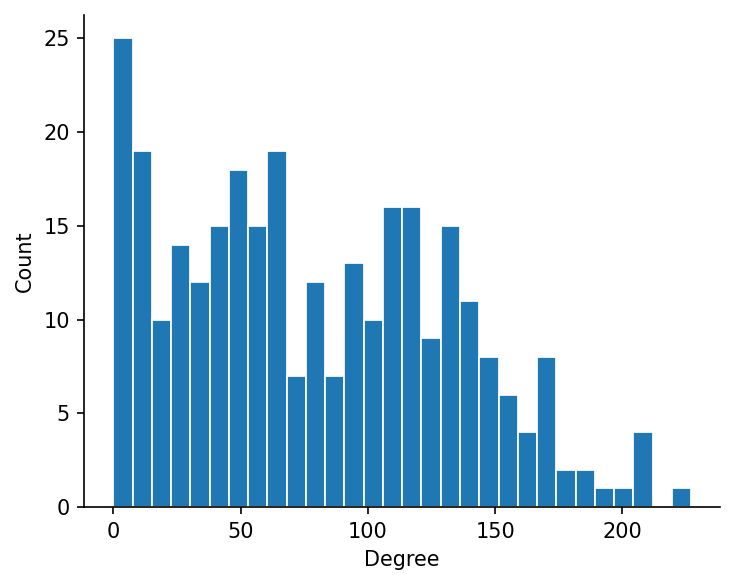

In [58]:
# degree distribution

# plt.rcdefaults()
plt.figure(figsize=(5,4), dpi=150)

# tmp = df.reset_index(names='gene')
# tmp = tmp[tmp['gene'] != 'MYOD1']

sns.histplot(
    df,
    x='degree',
    bins=30,
    # stat='frequency',
    # color='#C52E19', 
    alpha=1,
    ec='white',
    # log_scale=True,
)

plt.xlabel("Degree")
# plt.ylabel("Frequency")
# plt.xscale('log')

sns.despine()
plt.tight_layout()
plt.show()

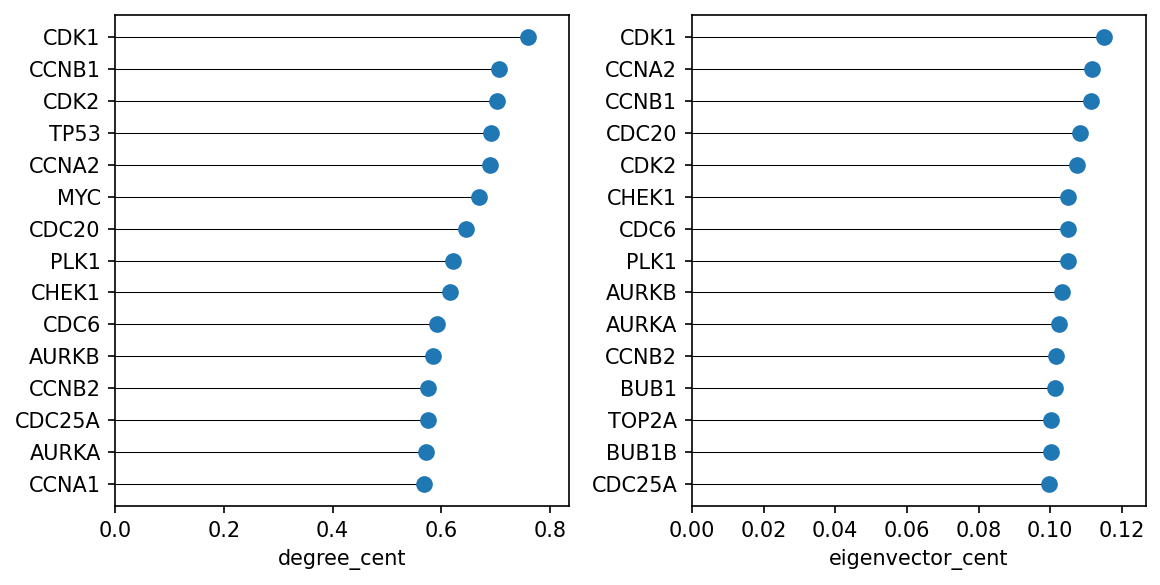

In [59]:
plt.rcParams['figure.dpi'] = 150
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=False)

df.head()

n_genes = 15

plot_cols = ['degree_cent', 'eigenvector_cent']

for i, col in enumerate(plot_cols):
    ax = axes[i]
    
    tmp = df[[col]].copy()
    tmp = tmp.reset_index(names='gene')
    
    tmp = tmp.sort_values(by=col, ascending=False).head(n_genes)
    tmp = tmp.sort_values(by=col, ascending=True)
    
    # top_genes = tmp.head(n_genes).index.to_list()
    
    ax.hlines(y=tmp['gene'], xmin=0, xmax=tmp[col], color='k', linewidth=0.5)
    ax.plot(tmp[col], tmp['gene'], "o", markersize=7)
    
    # ax.set_title(f"{col}", fontsize=10, fontweight='bold')
    ax.set_xlabel(f'{col}')
    ax.margins(x=0.05)
    
    # Set x-limit slightly higher than max for breathing room
    if not tmp.empty:
        ax.set_xlim([0, tmp[col].max() * 1.1])

plt.tight_layout()
plt.show()

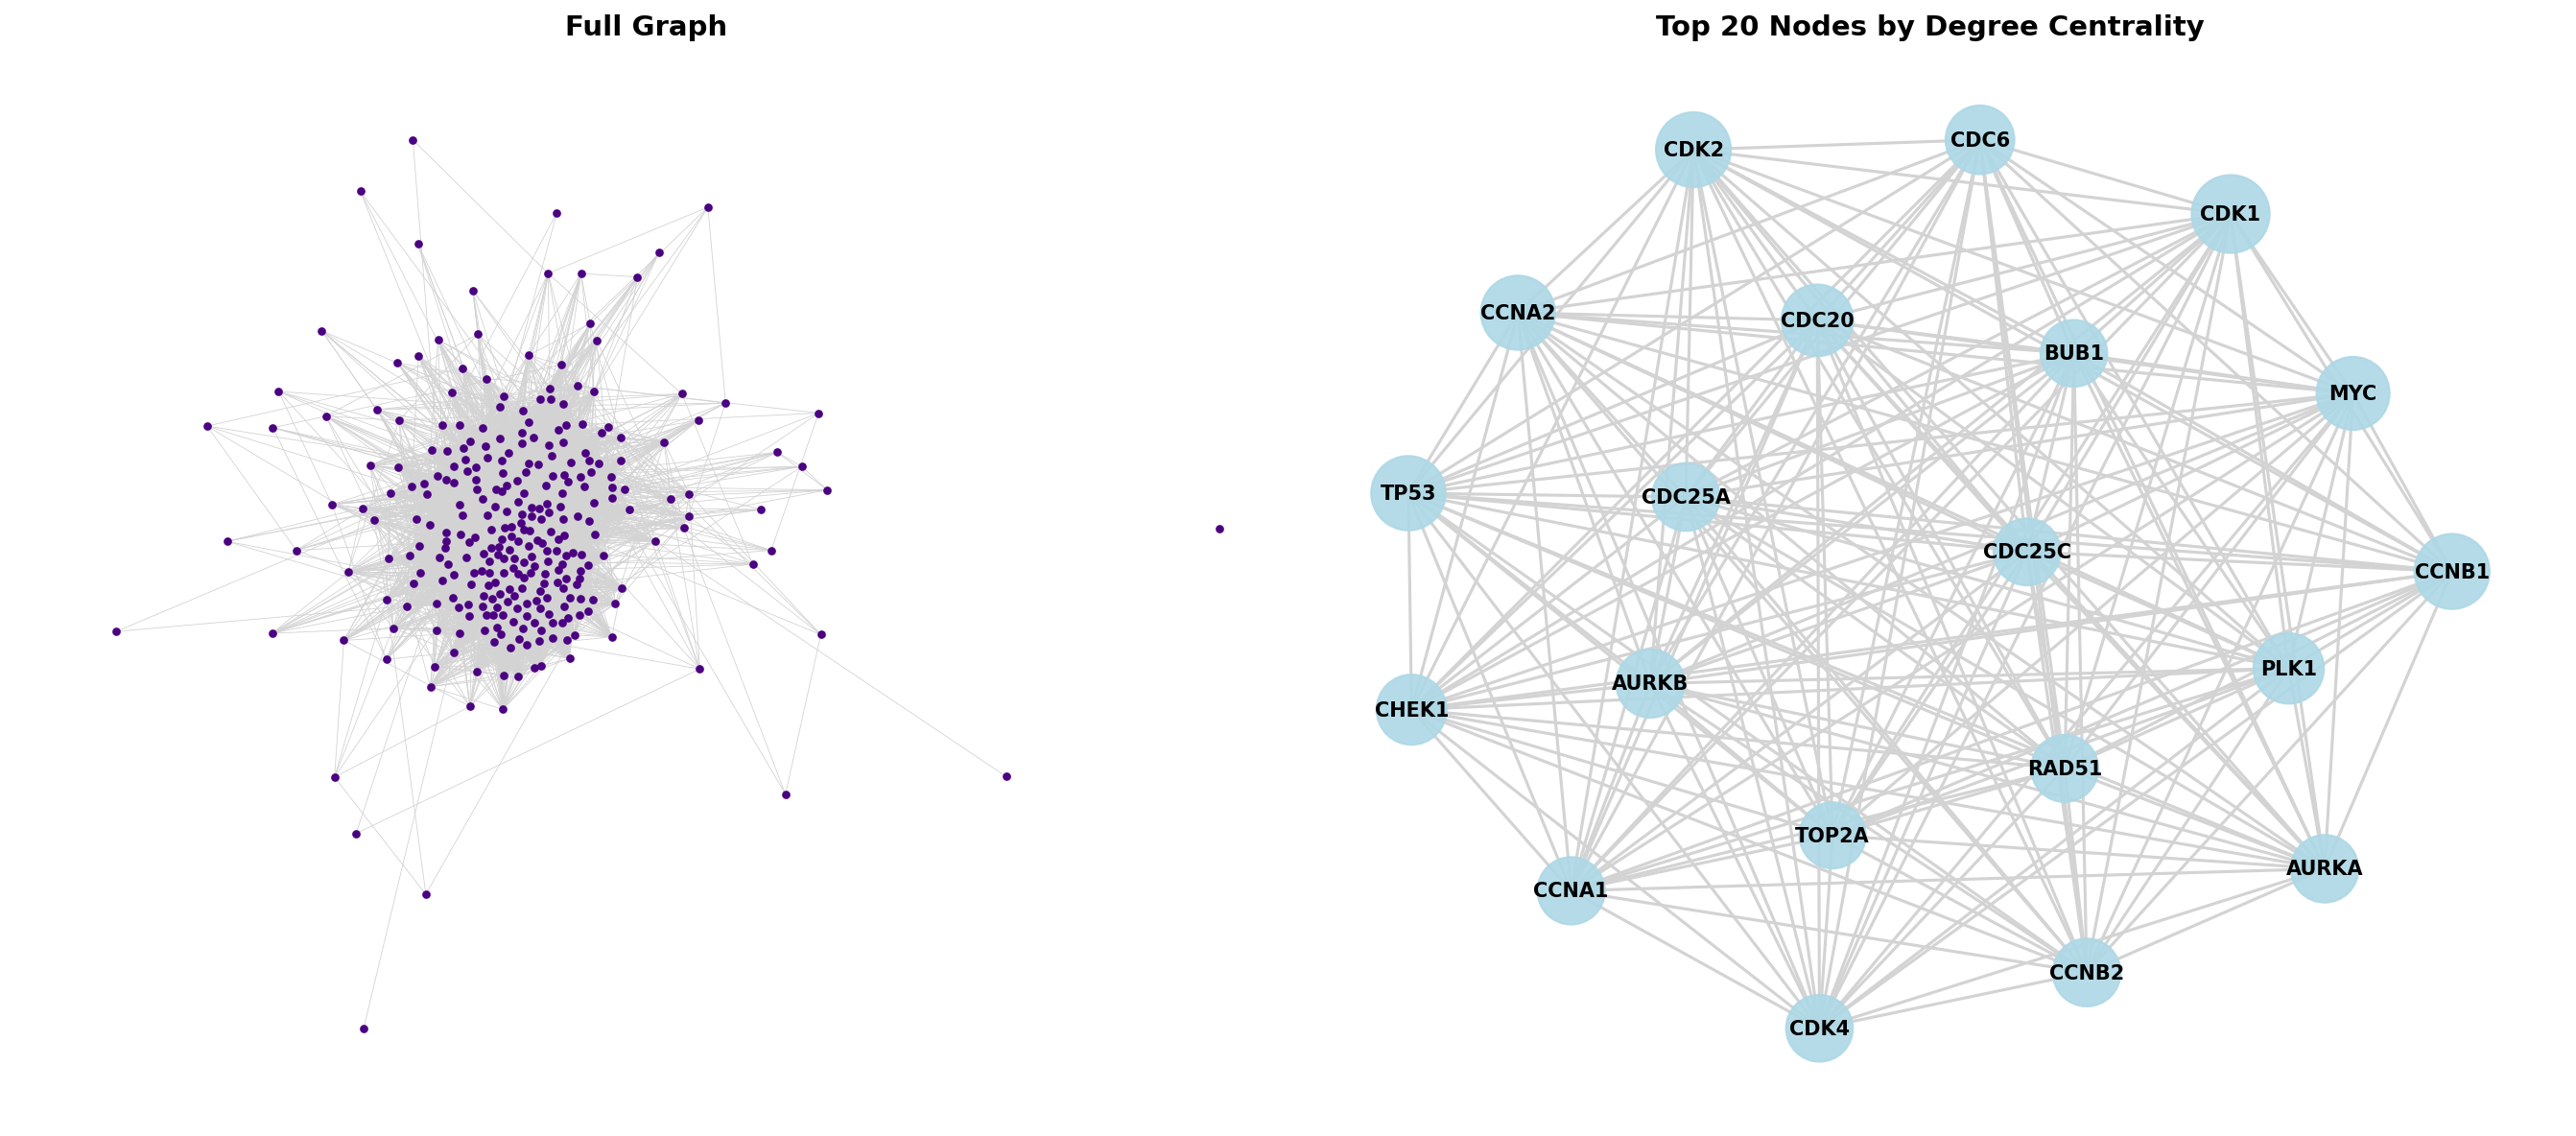

In [60]:
import matplotlib.gridspec as gridspec

# centrality = nx.eigenvector_centrality(G, max_iter=1000)
centrality = nx.degree_centrality(G)
top20_nodes = sorted(centrality, key=centrality.get, reverse=True)[:20]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Use a fast layout for large graphs
pos_full = nx.spring_layout(G, seed=42, k=0.3)
# pos_full = nx.kamada_kawai_layout(G)

nx.draw_networkx(
    G,
    pos=pos_full,
    ax=axes[0],
    with_labels=False,       # no labels
    node_size=10,            # tiny nodes
    node_color="indigo",
    edge_color="lightgray",
    # alpha=0.6,
    width=0.4,               # thin edges
)
axes[0].set_title("Full Graph", fontsize=14, fontweight="bold")
axes[0].axis("off")

# ── Plot 2: Top 20 nodes by  centrality ───────────────────────────
subG = G.subgraph(top20_nodes)

# Size nodes by their centrality score
node_sizes = [centrality[n] * 2000 for n in subG.nodes()]
node_colors = [centrality[n] for n in subG.nodes()]

pos_sub = nx.spring_layout(subG, seed=42)

nodes = nx.draw_networkx_nodes(
    subG, pos=pos_sub, ax=axes[1],
    node_size=node_sizes,
    node_color='lightblue',
    # node_color=node_colors,
    # cmap=plt.cm.plasma,
    alpha=0.9,
)
nx.draw_networkx_edges(
    subG, pos=pos_sub, ax=axes[1],
    edge_color="lightgray", width=1.5, #alpha=0.7,
)
nx.draw_networkx_labels(
    subG, pos=pos_sub, ax=axes[1],
    font_size=10, font_weight="bold",
)

axes[1].set_title("Top 20 Nodes by Degree Centrality", fontsize=14, fontweight="bold")
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [156]:
M = G.copy()

comms = louvain_communities(
    M,
    seed=1,
    resolution=1, # 1.1
)


module_of = {n: i for i, comm in enumerate(comms) for n in comm}
nx.set_node_attributes(M, module_of, "module")

print("Nodes:", M.number_of_nodes(), "Edges:", M.number_of_edges())
print("Modules:", len(comms))
print("Module sizes:", sorted([len(c) for c in comms], reverse=True))


Q = modularity(M, comms)
print("Modularity Q:", Q)

Nodes: 300 Edges: 11906
Modules: 5
Module sizes: [127, 95, 43, 34, 1]
Modularity Q: 0.20212202668029863


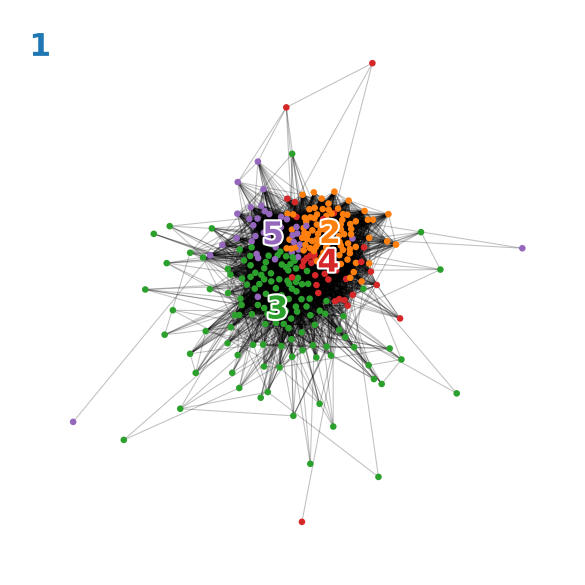

In [158]:
# pos = nx.spring_layout(M, seed=1)  # compute once, reuse across panels
pos = nx.spring_layout(M, seed=1729, k=0.3)

cmap = colormaps["tab10"]
node_colors = [cmap(module_of[n] % 20) for n in M.nodes()]

plt.figure(figsize=(4,4), dpi=150)
nx.draw_networkx_edges(M, pos, alpha=0.25, width=0.5, edge_color='k')
nx.draw_networkx_nodes(M, pos, node_color=node_colors, node_size=10, linewidths=0)

unique_modules = sorted(set(module_of[n] for n in M.nodes()))
for m in unique_modules:
    mod_nodes = [n for n in M.nodes() if module_of[n] == m]
    x = np.mean([pos[n][0] for n in mod_nodes])
    y = np.mean([pos[n][1] for n in mod_nodes])
    plt.gca().text(x, y, str(m+1), fontsize=15, ha='center', va='center',
            color=cmap(m % 20), fontweight='bold', path_effects=[pe.withStroke(linewidth=2, foreground='white')])

plt.axis("off")
plt.tight_layout()
plt.show()

In [159]:
modules = {i: sorted(list(nodes)) for i, nodes in enumerate(comms)}

# pd.set_option('display.max_colwidth', None)

database = "GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database='MSigDB_Hallmark_2020' 

results = {}

for module, nodes in modules.items():
    
    print(f"Module {module+1}: {len(nodes)} genes")

    enr = gget.enrichr(
        nodes,
        database,
        save=False,
    )

    enr = enr[enr['adj_p_val'] < 0.01]
    print(enr.columns)

    enr['adj_score'] = abs(np.log(enr['adj_p_val']) * enr['z_score'])
    
    results[f'{module+1}'] = enr
    
    # enr = enr.sort_values(by='adj_score', ascending=False)
    
    display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score', 'adj_score']].head(10))
    
    # break

13:08:40 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Module 1: 1 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Regulation of Activated T Cell Proliferation (GO:0046006),[BTN2A2],0.008775,19967.0,127928.560316,94561.057910
1,Negative Regulation of T Cell Proliferation (GO:0042130),[BTN2A2],0.008775,19961.0,124555.531625,94532.642708


13:08:40 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Module 2: 95 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


...

Module 4: 34 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,DNA Metabolic Process (GO:0006259),"[RTEL1, MCM7, PRKDC, SMC1A, TERF1, TERF2, ORC5, POLD3, ORC4, BRIP1, RAD51, MSH2, ORC3, RAD21, CHEK1, MCM3, RBBP8, TERF2IP, POLE]",7.746017e-24,88.098233,5206.690820,4688.135454
1,DNA Repair (GO:0006281),"[PCNA, PRKDC, SMC1A, UNG, POLD3, BRIP1, RAD51, MSH2, CHEK2, RAD21, CHEK1, RBBP8, POLE]",2.060434e-13,42.148789,1450.072030,1231.195188
2,DNA-templated DNA Replication (GO:0006261),"[ORC5, POLD3, ORC4, MCM7, ORC3, MCM3, POLE]",4.876913e-10,107.581790,2821.744515,2306.697583
3,DNA Strand Elongation Involved in DNA Replication (GO:0006271),"[POLD3, PCNA, MCM7, MCM3, POLE]",7.376476e-10,491.600985,12549.277587,10337.166719
4,DNA Recombination (GO:0006310),"[BRIP1, RTEL1, RAD51, MSH2, RAD21, RBBP8]",6.246040e-09,115.418919,2672.015438,2180.415524
5,Establishment of Mitotic Sister Chromatid Cohesion (GO:0034087),"[STAG2, RAD21, SMC1A, SMC3]",6.246040e-09,1330.933333,30592.384766,25143.085110
6,DNA Replication Initiation (GO:0006270),"[ORC5, ORC4, MCM7, ORC3, MCM3]",1.071355e-08,214.978448,4792.288973,3945.232206
7,DNA Damage Response (GO:0006974),"[BRIP1, RTEL1, RAD51, MCM7, MSH2, PRKDC, CHEK2, CHEK1, RBBP8, SMC1A]",5.769613e-08,19.824615,405.903799,330.438182
8,Telomere Maintenance (GO:0000723),"[RTEL1, RAD51, PRKDC, TERF2IP, TERF1, TERF2]",8.559667e-08,64.610390,1288.441283,1051.444894
9,DNA Replication (GO:0006260),"[ORC5, POLD3, MCM7, ORC3, CHEK1, POLE]",8.559667e-08,63.642857,1263.765023,1035.699639


13:08:41 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Module 5: 43 genes
Index(['rank', 'path_name', 'p_val', 'z_score', 'combined_score',
       'overlapping_genes', 'adj_p_val', 'database'],
      dtype='object')


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Mitotic Cell Cycle Phase Transition (GO:0044772),"[BRSK1, PLK3, BRSK2, USP37, CCDC57, PLK2, PLK1, ARPP19, CDC25B, PHF8, CCNA2, CCNB3, CCNB2, CCNB1, CDC23, CDK3, CDC27, ENSA, CDK14, ANAPC1, ANAPC2]",3.306958e-34,206.109190,17125.265582,15889.341700
1,Regulation of Meiotic Cell Cycle (GO:0051445),"[ANAPC13, ANAPC7, ANAPC10, ANAPC11, CDC20, FZR1, CDC23, CDC26, CDC16, CDC27, ANAPC4, ANAPC5, ANAPC2]",4.296621e-29,1235.000000,87216.248028,80666.666467
2,Anaphase-Promoting Complex-Dependent Catabolic Process (GO:0031145),"[ANAPC13, ANAPC7, ANAPC10, ANAPC11, CDC20, FZR1, CDC23, CDC26, CDC16, CDC27, ANAPC4, ANAPC5, ANAPC2]",7.509087e-29,1080.570833,75268.991405,69976.528571
3,Regulation of Mitotic Cell Cycle (GO:0007346),"[ANAPC13, ANAPC7, CCDC57, PLK1, ANAPC10, ANAPC11, CDC25B, CDC20, CCNB1, FZR1, CDC23, CDC26, CDC16, CDC27, ANAPC4, ANAPC5, ANAPC1, ANAPC2]",2.716833e-27,134.836981,8869.642446,8248.022696
4,Protein Branched Polyubiquitination (GO:0141198),"[ANAPC13, CDC23, ANAPC7, CDC26, CDC16, CDC27, ANAPC4, ANAPC5, ANAPC10, ANAPC11, ANAPC2]",2.842326e-24,979.687500,57414.031043,53116.128093
5,Protein K11-linked Ubiquitination (GO:0070979),"[ANAPC13, FZR1, CDC23, ANAPC7, CDC26, CDC27, CDC16, ANAPC4, ANAPC5, ANAPC10, ANAPC11, ANAPC2]",3.140906e-22,296.739454,15939.969097,14692.270904
6,G2/M Transition of Mitotic Cell Cycle (GO:0000086),"[CCNA2, BRSK1, PLK3, BRSK2, CCNB1, CCDC57, ENSA, PLK1, ARPP19, CDK14, CDC25B]",1.428717e-19,236.215517,11206.744798,10249.943939
7,Cell Cycle G2/M Phase Transition (GO:0044839),"[CCNA2, BRSK1, PLK3, BRSK2, CCNB1, CCDC57, ENSA, PLK1, ARPP19, CDK14, CDC25B]",3.096887e-19,214.038086,9960.418586,9122.029146
8,Protein K48-linked Ubiquitination (GO:0070936),"[ANAPC13, CDC23, ANAPC7, CDC26, CDC16, CDC27, ANAPC4, ANAPC5, ANAPC1, ANAPC10, ANAPC11, ANAPC2]",2.262507e-17,97.401388,4103.199140,3733.149106
9,Regulation of Mitotic Metaphase/Anaphase Transition (GO:0030071),"[CDC20, CCNB1, CDC23, ANAPC7, ESPL1, CDC16, PLK1, ANAPC5, CDC6, ANAPC11]",3.286517e-16,147.198817,5791.596371,5247.863517


In [48]:
df1 = df.reset_index(names='gene_name').copy()

df1[df1['gene_name'] == 'TP53']

,gene_name,degree,degree_cent,eigenvector_cent
23,TP53,208,0.693333,0.09631


In [49]:
# edges = pd.DataFrame(
#     [(u, v) for u, v in G.edges()],
#     columns=['gene1', 'gene2'],
# )

# print(edges.shape)
# edges.head()

# gene = 'MYOD1'

# sub = edges[(edges['gene1'] == gene) | (edges['gene2'] == gene)].copy()
# print(sub.shape)
# display(sub)

(11947, 2)
(41, 2)


,gene1,gene2
179,HDAC1,MYOD1
1467,PBX1,MYOD1
2495,NES,MYOD1
2820,CENPA,MYOD1
4235,GSK3B,MYOD1
5081,CCNA2,MYOD1
5416,CCNB1,MYOD1
5882,SKP1,MYOD1
6126,ID4,MYOD1
6295,CDKN1A,MYOD1


# Load gene data

In [161]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 9.00 GB, difference +4.94 GB
CPU times: user 547 ms, sys: 1.94 s, total: 2.49 s
Wall time: 7.22 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [162]:
# save normalized counts

adata.X = adata.layers['raw_counts'].copy()

sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

adata.layers['CP10K'] = adata.X.copy()

adata

normalizing counts per cell
    finished (0:00:02)


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [163]:
# Create a collapsed phase column
adata.obs['phase_grouped'] = adata.obs['phase'].replace({
    'G1': 'G1S',
    'S': 'G1S',
    'G2M': 'G2M'
})

# Create the combined grouping column
adata.obs['cond_phase_group'] = (
    adata.obs['pooled_condition'].astype(str) + '_' +
    adata.obs['phase_grouped'].astype(str)
)

adata.obs["cond_phase_group"].value_counts(sort=False)

/tmp/ipykernel_989158/2927426421.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['phase_grouped'] = adata.obs['phase'].replace({


cond_phase_group
siPRRX1/mmMYOD1_G2M     818
mmMYOD1_G1S            1924
siPRRX1/mmMYOD1_G1S    2638
siPRRX1_G2M            1485
mmMYOD1_G2M             331
siPRRX1_G1S            2198
Control_G2M            2980
Control_G1S            3922
Name: count, dtype: int64

In [112]:
# subset for conditions of interest

# cond = 'mmMYOD1'

# fdata = adata[adata.obs['pooled_condition'].isin(['Control', f'{cond}']), :].copy()
# print(fdata.shape)



cond = 'mmMYOD1_G1S'

fdata = adata[adata.obs['cond_phase_group'].isin(['Control_G1S', f'{cond}']), :].copy()
print(fdata.shape)

(5846, 25126)


In [113]:
### Which genes are present in adata?
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])


cc_nodes = list(G.nodes())
print(len(cc_nodes))

cc_genes = [g for g in cc_nodes if g in fdata.var_names]

missing_cc_genes = list(set(cc_nodes) - set(cc_genes))


print(f"N cc nodes in adata: {len(cc_genes)}")
print(f"{len(missing_cc_genes)} genes not detected.\n")
print("Missing genes:", ", ".join(missing_cc_genes))

300
N cc nodes in adata: 293
7 genes not detected.

Missing genes: USP29, DRD2, DRD3, USH1C, WEE2, TRIM71, PTTG2


# Pseudobulk

In [33]:
# # get mean log-norm counts per condition

# aggdata = sc.get.aggregate(
#     fdata,
#     by='pooled_condition',
#     func='mean',
#     layer='log_norm',
# )

# aggdata.X = aggdata.layers['mean'].copy()

# X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

# df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

# df = df.reset_index()

# print(df.shape)
# df.head()

(25126, 3)


,gene_name,Control,mmMYOD1
0,A1BG,0.471535,0.298099
1,A1BG-AS1,0.031917,0.062449
2,A1CF,0.000119,0.006221
3,A2M,0.087027,0.007885
4,A2M-AS1,0.002174,0.002501


In [114]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 2 × 25126
    obs: 'cond_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(25126, 3)


,gene_name,Control_G1S,mmMYOD1_G1S
0,A1BG,0.674243,0.419632
1,A1BG-AS1,0.047550,0.090898
2,A1CF,0.000401,0.010733
3,A2M,0.139678,0.013157
4,A2M-AS1,0.002802,0.003428


In [81]:
cdf = df[df['gene_name'].isin(cc_nodes)].copy()
print(cdf.shape)


# ---------- Add % expressing per condition columns ----------
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for MYOD network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(G.nodes()), layer="raw_counts", threshold=0
)

cdf = cdf.merge(pct_df, on='gene_name', how='left')
print(cdf.shape)
cdf.head()

(293, 3)
(293, 5)


,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1
0,ABCB1,0.001097,0.026845,0.001449,0.023060
1,ABL1,0.174309,0.401066,0.234280,0.384479
2,ACVR1B,0.036069,0.081091,0.051579,0.086475
3,AMBRA1,0.375143,0.459939,0.474500,0.461197
4,ANAPC1,0.083172,0.253034,0.113590,0.261197


In [82]:
cdf[['Control', f'{cond}']].describe()

,Control,mmMYOD1
count,293.000000,293.000000
mean,0.463683,0.454563
std,0.522919,0.456730
min,0.000000,0.000812
25%,0.122609,0.165089
50%,0.290080,0.330371
75%,0.612224,0.591179
max,3.384107,3.203584


In [83]:
# ---------- Set expr to 0 for genes expressed in less than 10% of cells per group ----------
conditions = ['Control', f'{cond}']#, 'siPRRX1', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    cdf.loc[cdf[pct_col] < min_pct, expr_col] = 0
    
display(cdf.head())

# pct_cols = [pct_prefix + cond for cond in conditions]

print(f"\nN genes expressed in >= 10% of cells for...\n")

total_genes = cdf.shape[0]

for col in conditions:
    nonzero_genes = (cdf[col] != 0).sum()
    print(f"{col}: {nonzero_genes} genes\n% of total nodes = {nonzero_genes/total_genes*100:.2f}%\n")

,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1
0,ABCB1,0.000000,0.000000,0.001449,0.023060
1,ABL1,0.174309,0.401066,0.234280,0.384479
2,ACVR1B,0.000000,0.000000,0.051579,0.086475
3,AMBRA1,0.375143,0.459939,0.474500,0.461197
4,ANAPC1,0.083172,0.253034,0.113590,0.261197



N genes expressed in >= 10% of cells for...

Control: 244 genes
% of total nodes = 83.28%

mmMYOD1: 244 genes
% of total nodes = 83.28%



In [88]:
# create subgraph with only expressed nodes per condition, then assign weights
def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
        # Create a distance attribute: small value for high activity
        # We add a tiny epsilon (1e-9) to avoid division by zero
        Gw[u][v]["distance"] = 1.0 / (float(w) + 1e-9)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]


# ---------- Create weighted subgraphs ----------

# use same node set
node_list = cdf[~((cdf['Control'] == 0) & (cdf[f'{cond}'] == 0))]['gene_name'].unique()
print(len(node_list))

# Control
# ctrl_nodes = nmdf[nmdf['Control'] != 0]['gene_name'].unique()
# CGM = GM.subgraph(ctrl_nodes).copy()
CGM = G.subgraph(node_list).copy()
n_edges = CGM.number_of_edges()
n_nodes = CGM.number_of_nodes()
print(f"Control - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

a_ctrl = dict(zip(cdf["gene_name"], cdf["Control"]))
wCGM = add_edge_weights_from_node_activity(CGM, a_ctrl, weight_attr="weight", combine="product")


# mmMYOD1
# mmy_nodes = nmdf[nmdf['mmMYOD1'] != 0]['gene_name'].unique()
# MGM = GM.subgraph(mmy_nodes).copy()
MGM = G.subgraph(node_list).copy()
n_edges = MGM.number_of_edges()
n_nodes = MGM.number_of_nodes()
print(f"{cond} - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

a_mmy = dict(zip(cdf["gene_name"], cdf[f'{cond}']))
wMGM = add_edge_weights_from_node_activity(MGM, a_mmy, weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(wCGM))
print(f"\nSum edge weight (Control): {ctrl_sum:.3f}")

m_sum = sum(edge_weight_series(wMGM))
print(f"Sum edge weight ({cond}): {m_sum:.3f}")

254
Control - N nodes: 254, N edges: 9821
Density = 0.3057
mmMYOD1 - N nodes: 254, N edges: 9821
Density = 0.3057

Sum edge weight (Control): 2934.637
Sum edge weight (mmMYOD1): 2431.569


In [85]:
def total_w(G, weight="weight"):
    return sum(d.get(weight, 0.0) for _,_,d in G.edges(data=True))

base = G.subgraph(node_list).copy()

Wc = total_w(wCGM)
Wm = total_w(wMGM)

print("Edges:", base.number_of_edges(), " Nodes:", base.number_of_nodes())
print("Total weight control:", Wc)
print(f"Total weight {cond}:", Wm)
print("Fold-change (treat/ctrl):", Wm / Wc if Wc else np.nan)
print("log2FC:", np.log2((Wm + 1e-12)/(Wc + 1e-12)))

Edges: 9821  Nodes: 254
Total weight control: 2934.6369617495534
Total weight mmMYOD1: 2431.568537479517
Fold-change (treat/ctrl): 0.8285755850460903
log2FC: -0.27129478464974077


In [86]:
eps = 1e-12
edges = list(base.edges())

wc = np.array([wCGM[u][v]["weight"] for u,v in edges], float)
wm = np.array([wMGM[u][v]["weight"]  for u,v in edges], float)

log2_ratio = np.log2((wm + eps) / (wc + eps))

print("Median log2 ratio:", np.median(log2_ratio))
print("Fraction edges increased:", np.mean(wm > wc))
print("Fraction edges decreased:", np.mean(wm < wc))

Median log2 ratio: -0.18039333951150494
Fraction edges increased: 0.43386620507076673
Fraction edges decreased: 0.5636900519295387


In [92]:
from scipy.stats import wilcoxon

eps = 1e-12
edges = list(base.edges())

wc = np.array([wCGM[u][v]["weight"] for u,v in edges], float)
wm = np.array([wMGM[u][v]["weight"]  for u,v in edges], float)

# optional: drop edges that are zero in both (uninformative)
mask = ~((wc == 0) & (wm == 0))
wc2, wm2 = wc[mask], wm[mask]

log2r = np.log2((wm2 + eps) / (wc2 + eps))
print("median log2(edge ratio):", np.median(log2r))
print("fraction edges increased:", np.mean(wm2 > wc2))
print("fraction edges decreased:", np.mean(wm2 < wc2))

stat, p = wilcoxon(log2r, alternative="less")  # tests median(log2r) < 0
print(f"Wilcoxon p ({cond} < Control):", f"{p:.4e}")

median log2(edge ratio): -0.18416982615014726
fraction edges increased: 0.43492905991630093
fraction edges decreased: 0.5650709400836991
Wilcoxon p (mmMYOD1 < Control): 2.6145e-40


## By cond_phase_group

In [164]:
adata

AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'phase_grouped', 'cond_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_t

In [166]:
# subset for conditions of interest
cond = 'mmMYOD1_G1S'

fdata = adata[adata.obs['cond_phase_group'].isin(['Control_G1S', f'{cond}']), :].copy()
fdata

AnnData object with n_obs × n_vars = 5846 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'phase_grouped', 'cond_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_to

In [167]:
### Which genes are present in adata?
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])


cc_nodes = list(G.nodes())
print(len(cc_nodes))

cc_genes = [g for g in cc_nodes if g in fdata.var_names]

missing_cc_genes = list(set(cc_nodes) - set(cc_genes))


print(f"N cc nodes in adata: {len(cc_genes)}")
print(f"{len(missing_cc_genes)} genes not detected.\n")
print("Missing genes:", ", ".join(missing_cc_genes))

300
N cc nodes in adata: 293
7 genes not detected.

Missing genes: USP29, DRD2, DRD3, USH1C, WEE2, TRIM71, PTTG2


In [168]:
# aggdata = sc.get.aggregate(
#     fdata,
#     by='cond_phase_group',
#     func='sum',
#     layer='raw_counts',
# )

# aggdata.X = aggdata.layers['sum'].copy()

# sc.pp.normalize_total(aggdata, target_sum=1e4)
# aggdata.layers['CP10K'] = aggdata.X.copy()

# sc.pp.log1p(aggdata)
# aggdata.layers['log_norm'] = aggdata.X.copy()

# print(aggdata)

# aggdata.X = aggdata.layers['log_norm'].copy()

# X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

# df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

# df = df.reset_index()

# print(df.shape)
# df.head()

### mean of normalized counts
aggdata = sc.get.aggregate(
    fdata,
    by='cond_phase_group',
    func='mean',
    layer='CP10K',
)

aggdata.X = aggdata.layers['mean'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

(25126, 3)


,gene_name,Control_G1S,mmMYOD1_G1S
0,A1BG,0.974835,0.514891
1,A1BG-AS1,0.049722,0.104882
2,A1CF,0.000326,0.010664
3,A2M,0.162374,0.011340
4,A2M-AS1,0.003039,0.004166


In [169]:
df[['Control_G1S', f'{cond}']].describe()

,Control_G1S,mmMYOD1_G1S
count,25126.000000,25126.000000
mean,0.397994,0.397994
std,3.379466,2.494005
min,0.000000,0.000000
25%,0.001593,0.008864
50%,0.020100,0.055800
75%,0.145052,0.253044
max,294.232706,197.294134


In [176]:
df[['Control_G1S', f'{cond}']].sum()

Control_G1S    10000.000004
mmMYOD1_G1S     9999.999993
dtype: float64

In [170]:
cdf = df[df['gene_name'].isin(cc_nodes)].copy()
print(cdf.shape)


# ---------- Add % expressing per condition columns ----------
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for MYOD network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="cond_phase_group", genes=list(G.nodes()), layer="raw_counts", threshold=0
)

cdf = cdf.merge(pct_df, on='gene_name', how='left')
print(cdf.shape)
cdf.head()

(293, 3)
(293, 5)


,gene_name,Control_G1S,mmMYOD1_G1S,pct_expr_Control_G1S,pct_expr_mmMYOD1_G1S
0,ABCB1,0.001837,0.033440,0.002040,0.022869
1,ABL1,0.185218,0.560033,0.203468,0.382536
2,ACVR1B,0.037345,0.104726,0.046150,0.087318
3,AMBRA1,0.445718,0.606220,0.427333,0.452183
4,ANAPC1,0.074626,0.300156,0.088985,0.248441


In [179]:
print(cdf[['Control_G1S', f'{cond}']].sum())
cdf[['Control_G1S', f'{cond}']].describe()

Control_G1S    188.929061
mmMYOD1_G1S    217.251427
dtype: float64


,Control_G1S,mmMYOD1_G1S
count,293.000000,293.000000
mean,0.644809,0.741472
std,2.287495,1.807383
min,0.000000,0.000000
25%,0.000000,0.155424
50%,0.195002,0.325802
75%,0.445718,0.664632
max,30.362724,22.371321


In [181]:
plot_df = cdf.melt(
    id_vars='gene_name', 
    value_vars=['Control_G1S', 'mmMYOD1_G1S'],
    var_name='condition',
    value_name='expression',
)

plot_df.head()

,gene_name,condition,expression
0,ABCB1,Control_G1S,0.000000
1,ABL1,Control_G1S,0.185218
2,ACVR1B,Control_G1S,0.000000
3,AMBRA1,Control_G1S,0.445718
4,ANAPC1,Control_G1S,0.000000


<Figure size 600x450 with 0 Axes>

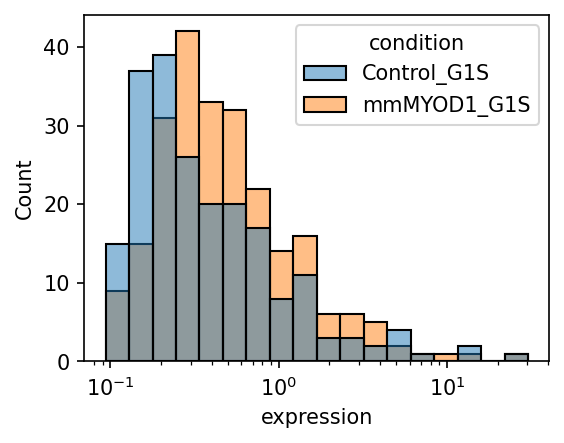

In [186]:
plt.figure(figsize=(4, 3), dpi=150)

# sns.boxplot(
#     data=plot_df,
#     x='condition',
#     y='expression',
# )

# plt.yscale('log')

sns.histplot(
    data=plot_df,
    x='expression',
    hue='condition',
    log_scale=True,
)

plt.show()

In [171]:
# ---------- Set expr to 0 for genes expressed in less than 10% of cells per group ----------
conditions = ['Control_G1S', f'{cond}']#, 'siPRRX1', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    cdf.loc[cdf[pct_col] < min_pct, expr_col] = 0
    
display(cdf.head())

# pct_cols = [pct_prefix + cond for cond in conditions]

print(f"\nN genes expressed in >= 10% of cells for...\n")

total_genes = cdf.shape[0]

for col in conditions:
    nonzero_genes = (cdf[col] != 0).sum()
    print(f"{col}: {nonzero_genes} genes\n% of total nodes = {nonzero_genes/total_genes*100:.2f}%\n")

,gene_name,Control_G1S,mmMYOD1_G1S,pct_expr_Control_G1S,pct_expr_mmMYOD1_G1S
0,ABCB1,0.000000,0.000000,0.002040,0.022869
1,ABL1,0.185218,0.560033,0.203468,0.382536
2,ACVR1B,0.000000,0.000000,0.046150,0.087318
3,AMBRA1,0.445718,0.606220,0.427333,0.452183
4,ANAPC1,0.000000,0.300156,0.088985,0.248441



N genes expressed in >= 10% of cells for...

Control_G1S: 209 genes
% of total nodes = 71.33%

mmMYOD1_G1S: 237 genes
% of total nodes = 80.89%



In [172]:
# create subgraph with only expressed nodes per condition, then assign weights
def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
        # Create a distance attribute: small value for high activity
        # We add a tiny epsilon (1e-9) to avoid division by zero
        Gw[u][v]["distance"] = 1.0 / (float(w) + 1e-9)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]


# ---------- Create weighted subgraphs ----------

# use same node set
node_list = cdf[~((cdf['Control_G1S'] == 0) & (cdf[f'{cond}'] == 0))]['gene_name'].unique()
print(len(node_list))

# Control
# ctrl_nodes = nmdf[nmdf['Control'] != 0]['gene_name'].unique()
# CGM = GM.subgraph(ctrl_nodes).copy()
CGM = G.subgraph(node_list).copy()
n_edges = CGM.number_of_edges()
n_nodes = CGM.number_of_nodes()
print(f"Control - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

a_ctrl = dict(zip(cdf["gene_name"], cdf["Control_G1S"]))
wCGM = add_edge_weights_from_node_activity(CGM, a_ctrl, weight_attr="weight", combine="product")


# mmMYOD1
# mmy_nodes = nmdf[nmdf['mmMYOD1'] != 0]['gene_name'].unique()
# MGM = GM.subgraph(mmy_nodes).copy()
MGM = G.subgraph(node_list).copy()
n_edges = MGM.number_of_edges()
n_nodes = MGM.number_of_nodes()
print(f"{cond} - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

a_mmy = dict(zip(cdf["gene_name"], cdf[f'{cond}']))
wMGM = add_edge_weights_from_node_activity(MGM, a_mmy, weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(wCGM))
print(f"\nSum edge weight (Control): {ctrl_sum:.3f}")

m_sum = sum(edge_weight_series(wMGM))
print(f"Sum edge weight ({cond}): {m_sum:.3f}")

237
Control - N nodes: 237, N edges: 8025
Density = 0.2870
mmMYOD1_G1S - N nodes: 237, N edges: 8025
Density = 0.2870

Sum edge weight (Control): 4128.967
Sum edge weight (mmMYOD1_G1S): 5510.269


In [173]:
def total_w(G, weight="weight"):
    return sum(d.get(weight, 0.0) for _,_,d in G.edges(data=True))

base = G.subgraph(node_list).copy()

Wc = total_w(wCGM)
Wm = total_w(wMGM)

print("Edges:", base.number_of_edges(), " Nodes:", base.number_of_nodes())
print("Total weight control:", Wc)
print(f"Total weight {cond}:", Wm)
print("Fold-change (treat/ctrl):", Wm / Wc if Wc else np.nan)
print("log2FC:", np.log2((Wm + 1e-12)/(Wc + 1e-12)))

Edges: 8025  Nodes: 237
Total weight control: 4128.966508187236
Total weight mmMYOD1_G1S: 5510.268937646038
Fold-change (treat/ctrl): 1.3345395092742571
log2FC: 0.4163420173497082


In [174]:
eps = 1e-12
edges = list(base.edges())

wc = np.array([wCGM[u][v]["weight"] for u,v in edges], float)
wm = np.array([wMGM[u][v]["weight"]  for u,v in edges], float)

log2_ratio = np.log2((wm + eps) / (wc + eps))

print("Median log2 ratio:", np.median(log2_ratio))
print("Fraction edges increased:", np.mean(wm > wc))
print("Fraction edges decreased:", np.mean(wm < wc))

Median log2 ratio: 1.4742897793791068
Fraction edges increased: 0.9297196261682243
Fraction edges decreased: 0.0702803738317757


In [175]:
eps = 1e-12
edges = list(base.edges())

wc = np.array([wCGM[u][v]["weight"] for u,v in edges], float)
wm = np.array([wMGM[u][v]["weight"]  for u,v in edges], float)

# optional: drop edges that are zero in both (uninformative)
mask = ~((wc == 0) & (wm == 0))
wc2, wm2 = wc[mask], wm[mask]

log2r = np.log2((wm2 + eps) / (wc2 + eps))
print("median log2(edge ratio):", np.median(log2r))
print("fraction edges increased:", np.mean(wm2 > wc2))
print("fraction edges decreased:", np.mean(wm2 < wc2))

stat, p = wilcoxon(log2r, alternative="two-sided")  # tests median(log2r) < 0
print(f"Wilcoxon p ({cond} = Control):", f"{p:.4e}")

median log2(edge ratio): 1.4742897793791068
fraction edges increased: 0.9297196261682243
fraction edges decreased: 0.0702803738317757
Wilcoxon p (mmMYOD1_G1S = Control): 0.0000e+00


# Centrailty comparison

In [125]:
# --- MYOD1 ---
deg1 = dict(wMGM.degree(weight='weight'))
clust1 = nx.clustering(wMGM, weight='weight')
eig1 = nx.eigenvector_centrality(wMGM, weight='weight')
# distance = 1/w --> algorithm interprets high weight as high distance, thus we took the inverse
# (Small distance = High importance)
betw1 = nx.betweenness_centrality(wMGM, weight='distance') 
close1 = nx.closeness_centrality(wMGM, distance='distance')

# weight='weight' uses your activity product (au * av)
pagerank1 = nx.pagerank(wMGM, weight='weight') 

df1 = pd.DataFrame({
    "strength": pd.Series(deg1),
    "clustering": pd.Series(clust1),
    "eigenvector": pd.Series(eig1),
    "pagerank": pd.Series(pagerank1),
    "betweenness": pd.Series(betw1),
    "closeness": pd.Series(close1),
})

df1 = df1.reset_index(names='gene_name')

display(df1.head())

# --- Control ---
deg2 = dict(wCGM.degree(weight='weight'))
clust2 = nx.clustering(wCGM, weight='weight')
eig2 = nx.eigenvector_centrality(wCGM, weight='weight')

betw2 = nx.betweenness_centrality(wCGM, weight='distance')
close2 = nx.closeness_centrality(wCGM, distance='distance')

pagerank2 = nx.pagerank(wCGM, weight='weight') 

df2 = pd.DataFrame({
    "strength": pd.Series(deg2),
    "clustering": pd.Series(clust2),
    "eigenvector": pd.Series(eig2),
    "pagerank": pd.Series(pagerank2),
    "betweenness": pd.Series(betw2),
    "closeness": pd.Series(close2),
})

df2 = df2.reset_index(names='gene_name')

display(df2.head())

,gene_name,strength,clustering,eigenvector,pagerank,betweenness,closeness
0,RCC1,5.172981,0.014803,0.015781,0.001772,0.0,0.197981
1,KHDRBS1,7.958488,0.037134,0.032180,0.002378,0.0,0.347670
2,HDAC1,8.936096,0.009563,0.020243,0.002734,0.0,0.214478
3,CDCA8,12.533114,0.015231,0.019085,0.003522,0.0,0.229982
4,CDC20,15.708350,0.009373,0.031668,0.004382,0.0,0.233981


,gene_name,strength,clustering,eigenvector,pagerank,betweenness,closeness
0,RCC1,1.846762,0.004787,5.031260e-03,0.001433,0.000000,8.666823e-09
1,KHDRBS1,5.749776,0.019707,2.265429e-02,0.002838,0.000000,8.666823e-09
2,HDAC1,9.606156,0.006316,2.024251e-02,0.004603,0.000019,8.666823e-09
3,CDCA8,5.190488,0.005290,4.087827e-03,0.002917,0.000029,8.666823e-09
4,CDC20,0.000000,0.000000,1.255369e-22,0.000704,0.000175,9.750177e-10


In [126]:
df = pd.merge(df1, df2, how='left', on='gene_name', suffixes=['_m', '_c'])
print(df.shape)
df.head()

(237, 13)


,gene_name,strength_m,clustering_m,eigenvector_m,pagerank_m,betweenness_m,closeness_m,strength_c,clustering_c,eigenvector_c,pagerank_c,betweenness_c,closeness_c
0,RCC1,5.172981,0.014803,0.015781,0.001772,0.0,0.197981,1.846762,0.004787,5.031260e-03,0.001433,0.000000,8.666823e-09
1,KHDRBS1,7.958488,0.037134,0.032180,0.002378,0.0,0.347670,5.749776,0.019707,2.265429e-02,0.002838,0.000000,8.666823e-09
2,HDAC1,8.936096,0.009563,0.020243,0.002734,0.0,0.214478,9.606156,0.006316,2.024251e-02,0.004603,0.000019,8.666823e-09
3,CDCA8,12.533114,0.015231,0.019085,0.003522,0.0,0.229982,5.190488,0.005290,4.087827e-03,0.002917,0.000029,8.666823e-09
4,CDC20,15.708350,0.009373,0.031668,0.004382,0.0,0.233981,0.000000,0.000000,1.255369e-22,0.000704,0.000175,9.750177e-10


In [127]:
print(df[['strength_m', 'strength_c']].median())
df[['strength_m', 'strength_c']].describe()

strength_m    10.130267
strength_c     4.870736
dtype: float64


,strength_m,strength_c
count,237.000000,237.000000
mean,15.564749,8.827440
std,15.981305,11.779618
min,0.000000,0.000000
25%,5.028305,2.003006
50%,10.130267,4.870736
75%,21.066187,10.154847
max,91.143010,74.706869


In [128]:
rank_col = 'strength'

tmp = df.copy()

tmp['rank_m'] = tmp[f'{rank_col}_m'].rank(ascending=False)
tmp['rank_c'] = tmp[f'{rank_col}_c'].rank(ascending=False)

print(f"Top genes by node {rank_col} for mmMYOD1:")
display(tmp.sort_values(by=f'{rank_col}_m', ascending=False)[['gene_name', 'rank_m']].head(10))

print(f"Top genes by node {rank_col} for Control:")
display(tmp.sort_values(by=f'{rank_col}_c', ascending=False)[['gene_name', 'rank_c']].head(10))



tmp['rank_diff'] = tmp['rank_c'] - tmp['rank_m'] # positive means importance increased in mmMYOD1

print(f"\nTop genes that increased in {rank_col} in mmMYOD1:")
display(tmp.sort_values(by='rank_diff', ascending=False)[['gene_name', 'rank_m', 'rank_c', 'rank_diff']].head(10))

print(f"\nTop genes that decreased in {rank_col} in mmMYOD1:")
display(tmp.sort_values(by='rank_diff', ascending=True)[['gene_name', 'rank_m', 'rank_c', 'rank_diff']].head(10))

Top genes by node strength for mmMYOD1:


,gene_name,rank_m
72,SKP1,1.0
133,CCND1,2.0
75,GMNN,3.0
77,CDKN1A,4.0
226,RBX1,5.0
112,RPS6,6.0
142,HSPA8,7.0
101,MYC,8.0
67,PTTG1,9.0
104,YWHAZ,10.0


Top genes by node strength for Control:


,gene_name,rank_c
72,SKP1,1.0
226,RBX1,2.0
112,RPS6,3.0
217,YWHAB,4.0
142,HSPA8,5.0
104,YWHAZ,6.0
35,CALM2,7.0
133,CCND1,8.0
126,ITGB1,9.0
194,YWHAE,10.0



Top genes that increased in strength in mmMYOD1:


,gene_name,rank_m,rank_c,rank_diff
229,CHEK2,78.0,223.5,145.5
4,CDC20,81.0,223.5,142.5
196,AURKB,106.0,223.5,117.5
70,PLK2,24.0,139.0,115.0
103,CCNE2,120.0,223.5,103.5
63,SKP2,137.0,223.5,86.5
149,GAS2L3,150.0,223.5,73.5
10,GADD45A,16.0,81.0,65.0
37,ANAPC1,162.0,223.5,61.5
19,EXO1,163.0,223.5,60.5



Top genes that decreased in strength in mmMYOD1:


,gene_name,rank_m,rank_c,rank_diff
223,YWHAH,166.0,92.0,-74.0
222,APP,88.0,17.0,-71.0
24,CSDE1,172.0,107.0,-65.0
162,CDC16,149.0,86.0,-63.0
2,HDAC1,128.0,68.0,-60.0
206,SMAD2,158.0,100.0,-58.0
15,PBX1,214.0,157.0,-57.0
236,CUL4B,110.0,55.0,-55.0
161,TFDP1,170.0,116.0,-54.0
212,CALM3,67.0,16.0,-51.0


In [129]:
# Calculate what % of the total network strength each gene holds
tmp['pct_m'] = tmp[f'{rank_col}_m'] / tmp[f'{rank_col}_m'].sum()

tmp['pct_c'] = tmp[f'{rank_col}_c'] / tmp[f'{rank_col}_c'].sum()

display(tmp.sort_values(by='pct_m', ascending=False)[['gene_name', 'rank_m', 'pct_m']].head())
display(tmp.sort_values(by='pct_c', ascending=False)[['gene_name', 'rank_c', 'pct_c']].head())

,gene_name,rank_m,pct_m
72,SKP1,1.0,0.024708
133,CCND1,2.0,0.024659
75,GMNN,3.0,0.019044
77,CDKN1A,4.0,0.018458
226,RBX1,5.0,0.017953


,gene_name,rank_c,pct_c
72,SKP1,1.0,0.035709
226,RBX1,2.0,0.029432
112,RPS6,3.0,0.027284
217,YWHAB,4.0,0.025435
142,HSPA8,5.0,0.025430


In [130]:
# (Value - Mean) / Standard Deviation
# which genes are significantly more central than the "average" gene in that specific condition
tmp['z_m'] = (tmp[f'{rank_col}_m'] - tmp[f'{rank_col}_m'].mean()) / tmp[f'{rank_col}_m'].std()
tmp['z_c'] = (tmp[f'{rank_col}_c'] - tmp[f'{rank_col}_c'].mean()) / tmp[f'{rank_col}_c'].std()

display(tmp.sort_values(by='z_m', ascending=False)[['gene_name', 'rank_m', 'z_m']].head())
display(tmp.sort_values(by='z_c', ascending=False)[['gene_name', 'rank_c', 'z_c']].head())

,gene_name,rank_m,z_m
72,SKP1,1.0,4.729167
133,CCND1,2.0,4.718027
75,GMNN,3.0,3.421936
77,CDKN1A,4.0,3.286496
226,RBX1,5.0,3.169984


,gene_name,rank_c,z_c
72,SKP1,1.0,5.592663
226,RBX1,2.0,4.477928
112,RPS6,3.0,4.096275
217,YWHAB,4.0,3.767917
142,HSPA8,5.0,3.767105


In [131]:
# from scipy.stats import spearmanr, kendalltau

# Ensure both dataframes are aligned by gene index
df1 = df1.set_index('gene_name')
df2 = df2.set_index('gene_name')

common_genes = df1.index.intersection(df2.index)
print(len(common_genes))

s_corr, p_value = spearmanr(df1.loc[common_genes, 'strength'], 
                            df2.loc[common_genes, 'strength'])

print(f"Spearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'strength'], 
                            df2.loc[common_genes, 'strength'])

print(f"Kendall tau: {k_corr:.3f} (p={p_value:.3e})")

237
Spearman Correlation: 0.881 (p=2.031e-78)
Kendall tau: 0.714 (p=1.417e-59)


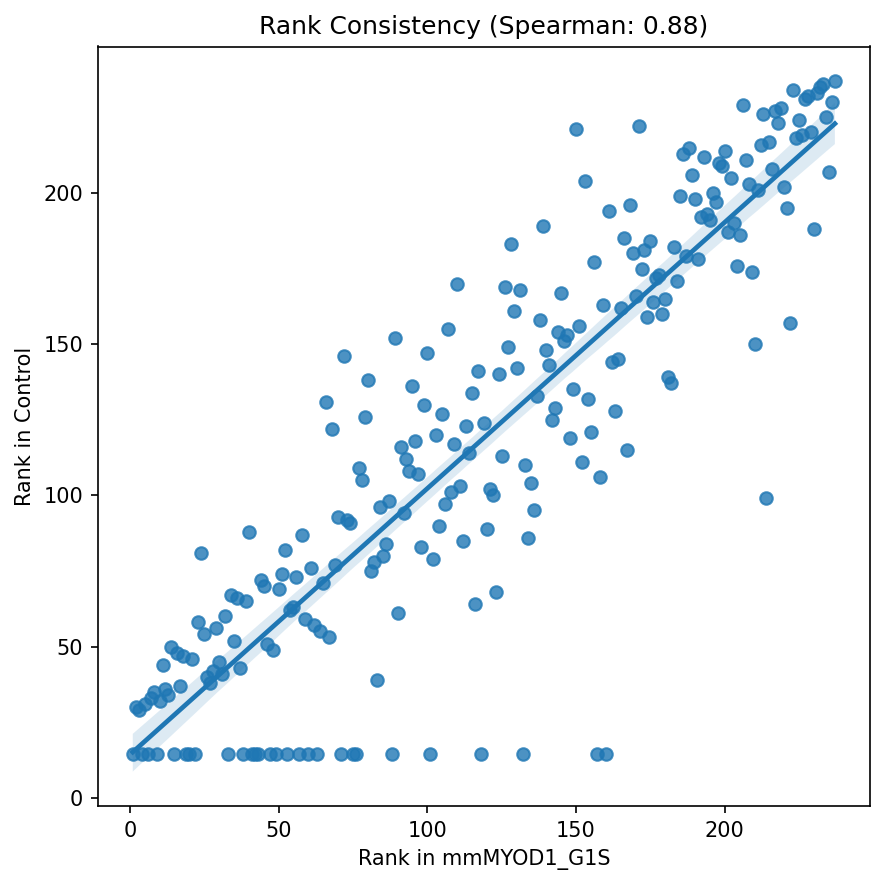

In [132]:
plt.figure(figsize=(6,6))
sns.regplot(x=df1['strength'].rank(), 
            y=df2['strength'].rank())

plt.xlabel(f'Rank in {cond}')
plt.ylabel('Rank in Control')
plt.title(f'Rank Consistency (Spearman: {s_corr:.2f})')

plt.tight_layout()
plt.show()

In [133]:
common_genes = df1.index.intersection(df2.index)
print(len(common_genes))

s_corr, p_value = spearmanr(df1.loc[common_genes, 'pagerank'], 
                            df2.loc[common_genes, 'pagerank'])

print(f"Spearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'pagerank'], 
                            df2.loc[common_genes, 'pagerank'])

print(f"Kendall tau: {k_corr:.3f} (p={p_value:.3e})")

237
Spearman Correlation: 0.882 (p=8.167e-79)
Kendall tau: 0.717 (p=4.463e-60)


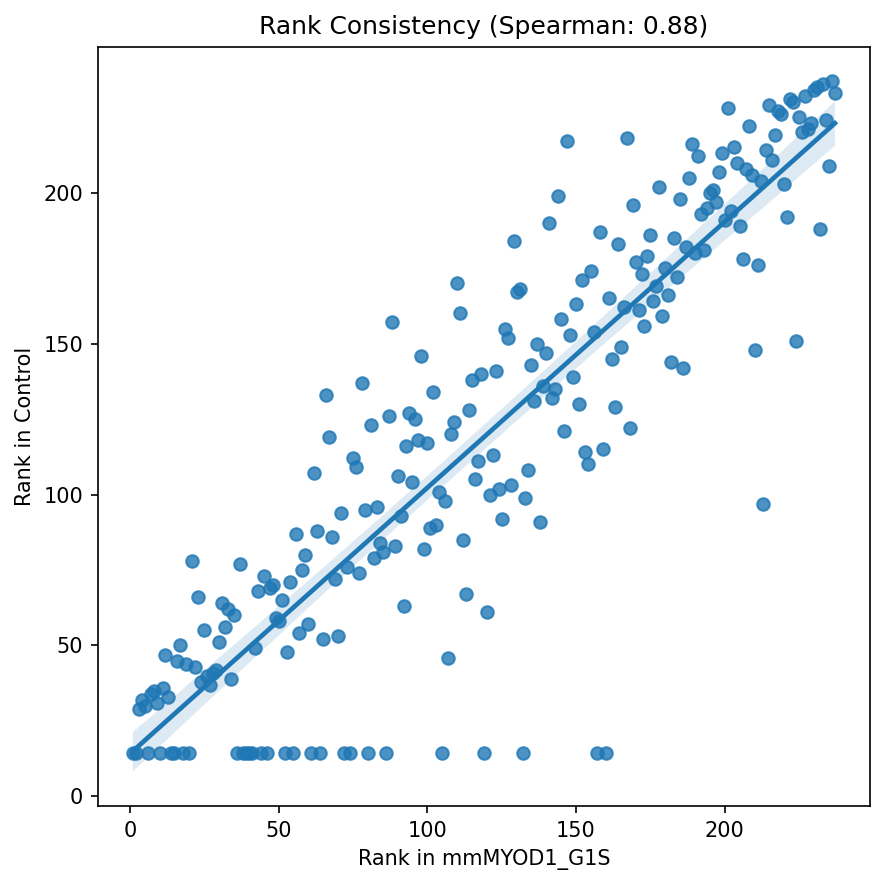

In [134]:
plt.figure(figsize=(6,6))
sns.regplot(x=df1['pagerank'].rank(), 
            y=df2['pagerank'].rank())

plt.xlabel(f'Rank in {cond}')
plt.ylabel('Rank in Control')
plt.title(f'Rank Consistency (Spearman: {s_corr:.2f})')

plt.tight_layout()
plt.show()

In [135]:
s_corr, p_value = spearmanr(df1.loc[common_genes, 'betweenness'], 
                            df2.loc[common_genes, 'betweenness'])

print(f"Spearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'betweenness'], 
                            df2.loc[common_genes, 'betweenness'])

print(f"Kendall tau: {k_corr:.3f} (p={p_value:.3e})")

Spearman Correlation: 0.496 (p=4.349e-16)
Kendall tau: 0.407 (p=8.217e-15)


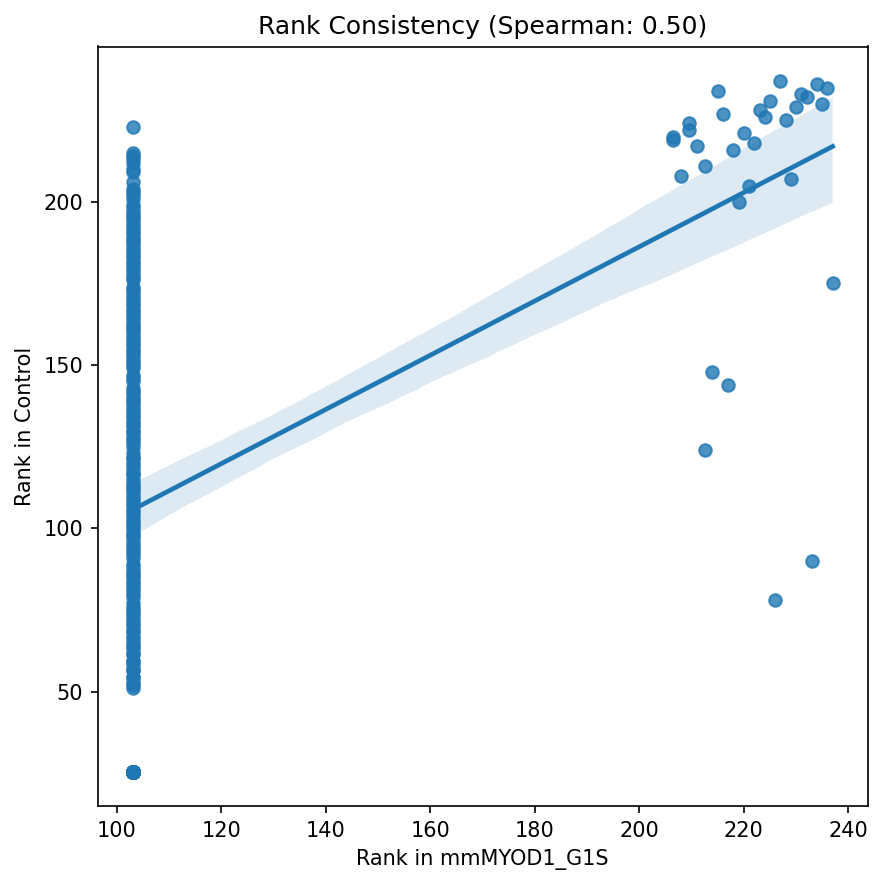

In [136]:
plt.figure(figsize=(6,6))
sns.regplot(x=df1['betweenness'].rank(), 
            y=df2['betweenness'].rank())

plt.xlabel(f'Rank in {cond}')
plt.ylabel('Rank in Control')
plt.title(f'Rank Consistency (Spearman: {s_corr:.2f})')

plt.tight_layout()
plt.show()

In [137]:
# Look for genes with high betweenness but low-to-mid strength in mmMYOD1
df1['bridge_score'] = df1['betweenness'] / (df1['strength'] + 1)
top_bridges = df1.sort_values('betweenness', ascending=False).head(20)


# Compare betweenness shifts specifically
betw_comp = pd.DataFrame({
    'Ctrl_Betw': df2['betweenness']/df2['betweenness'].max(),
    'MYOD1_Betw': df1['betweenness']/df1['betweenness'].max()
})

display(betw_comp[['Ctrl_Betw', 'MYOD1_Betw']].describe())


betw_comp['Delta_Betw'] = betw_comp['MYOD1_Betw'] - betw_comp['Ctrl_Betw']

print("Genes that became major bottlenecks in mmMYOD1:")
print(betw_comp.sort_values('Delta_Betw', ascending=False).head(20))

,Ctrl_Betw,MYOD1_Betw
count,237.000000,237.000000
mean,0.026372,0.025225
std,0.115891,0.125164
min,0.000000,0.000000
25%,0.000003,0.000000
50%,0.000057,0.000000
75%,0.000221,0.000000
max,1.000000,1.000000


Genes that became major bottlenecks in mmMYOD1:
           Ctrl_Betw  MYOD1_Betw  Delta_Betw
gene_name                                   
GMNN        0.000200    1.000000    0.999800
CCND1       0.291569    0.926424    0.634855
GADD45A     0.000023    0.587289    0.587267
SKP1        0.744082    0.961670    0.217588
PTTG1       0.013683    0.132283    0.118600
PLK2        0.000012    0.102544    0.102533
SMC4        0.003943    0.053640    0.049697
MYC         0.001483    0.051107    0.049624
MDM2        0.000076    0.031722    0.031645
TERF1       0.000087    0.025774    0.025687
MAD1L1      0.000059    0.025664    0.025605
MNAT1       0.051038    0.060139    0.009101
KHDRBS1     0.000000    0.000000    0.000000
MTA3        0.000000    0.000000    0.000000
SPDYA       0.000000    0.000000    0.000000
PELO        0.000000    0.000000    0.000000
CASP8AP2    0.000000    0.000000    0.000000
EIF4EBP1    0.000000    0.000000    0.000000
TAF2        0.000000    0.000000    0.000000
LATS1  

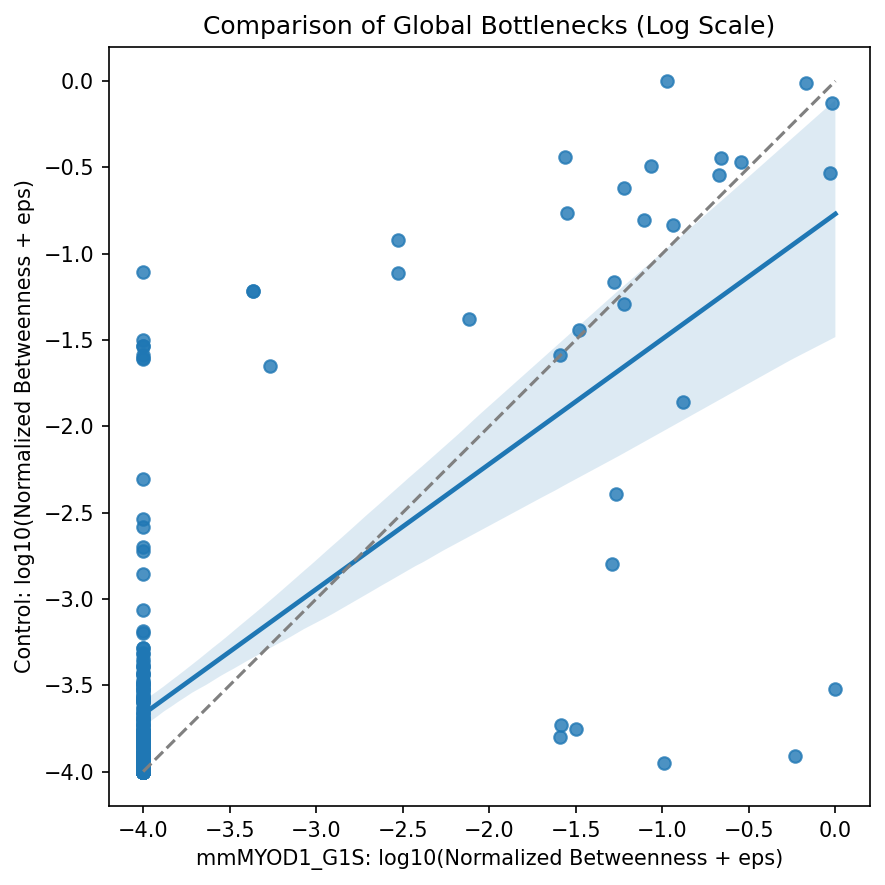

In [141]:
plt.figure(figsize=(6,6))

epsilon = 1e-4 
betw_comp['log_betw_m'] = np.log10(betw_comp['MYOD1_Betw'] + epsilon)
betw_comp['log_betw_c'] = np.log10(betw_comp['Ctrl_Betw'] + epsilon)

sns.regplot(x=betw_comp['log_betw_m'], 
            y=betw_comp['log_betw_c'],
           )

plt.ylabel('Control: log10(Normalized Betweenness + eps)')
plt.xlabel(f'{cond}: log10(Normalized Betweenness + eps)')
plt.title('Comparison of Global Bottlenecks (Log Scale)')

# Draw a diagonal line to show "no change"
plt.plot([-4, 0], [-4, 0], color='gray', linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
# Node strength (weighted degree) -- Best for showing which genes are the most "active" hubs
# Betweeness (using distance) -- Best for finding "bottleneck" genes that link different biological pathways
# PageRank (using weight) -- Best for finding genes that are part of the most "influential" core of the condition-specific response

In [139]:
pd.set_option('display.max_colwidth', None)

n_genes = 50

cols = ['rank_m', 'rank_c']

for col in cols:
    
    if col == 'rank_m':
        print("mmMYOD1:")
    if col == 'rank_c':
        print("Control:")
    
    gene_list = tmp.sort_values(col, ascending=True).head(n_genes)['gene_name'].unique()
    print(len(gene_list))


    database = "GO_Biological_Process_2025"
    # database="Reactome_Pathways_2024"
    # database="KEGG_2021_Human"
    # database='MSigDB_Hallmark_2020' 

    enr = gget.enrichr(
        gene_list,
        database,
        save=False,
    )

    enr = enr[enr['adj_p_val'] < 0.01]
    enr['adj_score'] = abs(np.log(enr['adj_p_val']) * enr['z_score'])
    enr = enr.sort_values(by='adj_score', ascending=False)

    display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score', 'adj_score']].head(11))

12:48:42 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


mmMYOD1:
50


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
8,Positive Regulation of G2/M Transition of Mitotic Cell Cycle (GO:0010971),"[RRM1, CCNB1, CCND1, CDK4, CDK1]",1.051847e-07,147.666667,3033.458647,2372.641232
9,Regulation of Cell Cycle G2/M Phase Transition (GO:1902749),"[CENPF, CDK6, CDK4, TP53, AURKA]",1.051847e-07,147.666667,3033.458647,2372.641232
2,Regulation of G2/M Transition of Mitotic Cell Cycle (GO:0010389),"[CCNB1, RRM1, CENPF, CDK6, CCND1, CDK4, CDK1]",1.120735e-09,108.093023,2841.583514,2227.719527
10,Positive Regulation of Cell Cycle G2/M Phase Transition (GO:1902751),"[RRM1, CCNB1, CCND1, CDK4, CDK1]",2.063713e-07,123.037037,2432.853173,1893.981548
52,Establishment of Mitotic Sister Chromatid Cohesion (GO:0034087),"[RAD21, SMC3]",1.512302e-03,207.770833,1932.575689,1349.289268
1,Mitotic Cell Cycle Phase Transition (GO:0044772),"[CCNB1, CDK6, CCND1, CDK4, UBE2C, MYC, PLK2, CDC27, CDK1, AURKA]",8.238174e-11,48.172330,1411.649509,1118.544995
57,ER Overload Response (GO:0006983),"[GSK3B, TP53]",1.898875e-03,166.208333,1490.324070,1041.543429
58,Positive Regulation of Ryanodine-Sensitive Calcium-Release Channel Activity (GO:0060316),"[CALM1, CALM2]",1.898875e-03,166.208333,1490.324070,1041.543429
5,Positive Regulation of Mitotic Cell Cycle Phase Transition (GO:1901992),"[CCNB1, RRM1, CCND1, CDK4, UBE2C, CDK1, ANAPC11]",3.213722e-08,56.813953,1263.493359,980.225399
4,G1/S Transition of Mitotic Cell Cycle (GO:0000082),"[CCNB1, CDK6, CCND1, CDK4, MYC, PLK2, CDK1]",3.213722e-08,56.813953,1263.493359,980.225399


12:48:42 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Control:
50


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
14,Establishment of Mitotic Sister Chromatid Cohesion (GO:0034087),"[RAD21, SMC1A, SMC3]",1.685825e-05,424.404255,6385.135183,4664.487210
17,Positive Regulation of Ryanodine-Sensitive Calcium-Release Channel Activity (GO:0060316),"[CALM3, CALM1, CALM2]",2.591437e-05,318.287234,4611.051692,3361.340116
66,Regulation of High Voltage-Gated Calcium Channel Activity (GO:1901841),"[CALM3, CALM1]",1.243987e-03,207.770833,1932.575689,1389.869284
11,Mitotic Sister Chromatid Cohesion (GO:0007064),"[RB1, RAD21, SMC1A, SMC3]",9.911501e-06,115.565217,1832.129812,1331.521025
24,Detection of Calcium Ion (GO:0005513),"[CALM3, CALM1, CALM2]",1.162542e-04,141.425532,1790.106623,1281.277350
12,Positive Regulation of G2/M Transition of Mitotic Cell Cycle (GO:0010971),"[RRM1, CCND1, CDK4, CDK1]",1.141535e-05,108.336957,1693.559945,1232.934333
25,Regulation of Cell Communication by Electrical Coupling (GO:0010649),"[CALM3, CALM1, CALM2]",1.450622e-04,127.276596,1577.846344,1124.914843
70,Negative Regulation of Voltage-Gated Calcium Channel Activity (GO:1901386),"[CALM3, CALM1]",1.640841e-03,166.208333,1490.324070,1065.818679
27,Meiotic Sister Chromatid Cohesion (GO:0051177),"[RAD21, SMC1A, SMC3]",1.711356e-04,115.700193,1406.634986,1003.474033
15,Positive Regulation of Cell Cycle G2/M Phase Transition (GO:1902751),"[RRM1, CCND1, CDK4, CDK1]",1.685825e-05,91.217391,1371.436820,1002.540266


In [140]:
# change in rank
n_genes = 50
sorts = [False, True]

for sort in sorts:

    if sort == False:
        print("Increased in rank in mmMYOD1:")
    if sort == True:
        print("Decreased in rank in mmMYOD1:")
    
    gene_list = tmp.sort_values('rank_diff', ascending=sort).head(n_genes)['gene_name'].unique()
    print(len(gene_list))


    database = "GO_Biological_Process_2025"
    # database="Reactome_Pathways_2024"
    # database="KEGG_2021_Human"
    # database='MSigDB_Hallmark_2020' 

    enr = gget.enrichr(
        gene_list,
        database,
        save=False,
    )

    enr = enr[enr['adj_p_val'] < 0.01]
    enr['adj_score'] = abs(np.log(enr['adj_p_val']) * enr['z_score'])
    enr = enr.sort_values(by='adj_score', ascending=False)

    display(enr[['path_name', 'overlapping_genes', 'adj_p_val', 'z_score', 'combined_score', 'adj_score']].head(11))

12:49:19 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Increased in rank in mmMYOD1:
50


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
0,Mitotic Cell Cycle Phase Transition (GO:0044772),"[PLK3, PLK2, CDC7, MASTL, PKMYT1, AURKA, CCNB1, DBF4, MELK, CCNE2, CHEK2, MYC, CDC27, NES, POLE, ANAPC1, CDKN3]",7.149860e-24,106.539773,6337.764700,5678.031807
2,Cell Cycle G2/M Phase Transition (GO:0044839),"[PLK3, CCNB1, MELK, CHEK2, PKMYT1, MASTL, NES, AURKB, AURKA]",1.534699e-13,128.582496,4448.828660,3793.861543
6,G2/M Transition of Mitotic Cell Cycle (GO:0000086),"[PLK3, CCNB1, MELK, CHEK2, PKMYT1, MASTL, NES, AURKA]",3.830403e-12,118.559524,3606.914238,3116.698811
4,G1/S Transition of Mitotic Cell Cycle (GO:0000082),"[PLK3, CCNB1, DBF4, CCNE2, PLK2, MYC, CDC7, POLE, CDKN3]",3.830403e-12,79.403548,2441.599267,2087.364513
46,Positive Regulation of Nuclear Cell Cycle DNA Replication (GO:0010571),"[DBF4, CDC7]",6.342100e-04,277.041667,2688.785055,2039.893939
5,Cell Cycle G1/S Phase Transition (GO:0044843),"[PLK3, CCNB1, DBF4, CCNE2, PLK2, MYC, CDC7, POLE, CDKN3]",3.830403e-12,76.609756,2333.326292,2013.921177
1,Regulation of Mitotic Cell Cycle (GO:0007346),"[CDC20, CCNB1, FZR1, CDC27, GMNN, MDM2, MASTL, PKMYT1, MKI67, KIF20B, ANAPC1, AURKA]",4.550911e-14,55.934211,2025.941538,1718.347271
49,Metaphase/Anaphase Transition of Cell Cycle (GO:0044784),"[CDC20, CDC27]",8.928091e-04,207.770833,1932.575689,1458.787654
11,Regulation of Cyclin-Dependent Protein Serine/Threonine Kinase Activity (GO:0000079),"[BLM, CCNE2, GADD45A, CDC6, PKMYT1, CDKN3]",6.330727e-08,67.875000,1376.689722,1125.046156
7,Regulation of Cell Cycle Process (GO:0010564),"[PLK3, DBF4, MYC, KIF2C, KIF11, PKMYT1, MKI67, KIF20B, BUB1, AURKB, AURKA]",3.830403e-12,41.398860,1258.565595,1088.295354


12:49:20 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2025.


Decreased in rank in mmMYOD1:
50


,path_name,overlapping_genes,adj_p_val,z_score,combined_score,adj_score
1,G2/M Transition of Mitotic Cell Cycle (GO:0000086),"[KHDRBS1, WEE1, PPME1, CCDC57, USP22, FBXL15, UBE2A, PLCB1, ARPP19, LCMT1]",1.329818e-15,166.000000,6701.906790,5686.119936
2,Cell Cycle G2/M Phase Transition (GO:0044839),"[KHDRBS1, WEE1, PPME1, CCDC57, USP22, FBXL15, UBE2A, PLCB1, ARPP19, LCMT1]",1.994416e-15,150.886364,5969.390151,5107.265785
0,Mitotic Cell Cycle Phase Transition (GO:0044772),"[KHDRBS1, CCDC57, USP22, CUL2, FBXL15, UBE2A, ARPP19, PPP6C, WEE1, PPME1, EIF4EBP1, BCAT1, PLCB1, LCMT1, CACUL1, CUL4B]",1.361775e-21,96.315343,5283.651957,4627.518605
7,Protein Branched Polyubiquitination (GO:0141198),"[CDC26, CDC16, ANAPC4, ANAPC5, ANAPC11]",7.550800e-08,170.401709,3600.917133,2794.422277
8,Regulation of Meiotic Cell Cycle (GO:0051445),"[CDC26, CDC16, ANAPC4, ANAPC5, ANAPC11]",1.209984e-07,147.666667,3033.458647,2351.959184
9,Anaphase-Promoting Complex-Dependent Catabolic Process (GO:0031145),"[CDC26, CDC16, ANAPC4, ANAPC5, ANAPC11]",1.426620e-07,138.430556,2806.339989,2182.051406
21,Positive Regulation of Metaphase/Anaphase Transition of Cell Cycle (GO:1902101),"[RB1, CDC16, ANAPC5]",9.881993e-05,159.111702,2059.464527,1467.361730
6,Protein K11-linked Ubiquitination (GO:0070979),"[CDC26, CDC16, ANAPC4, ANAPC5, UBE2A, ANAPC11]",6.036237e-08,84.877841,1823.968345,1410.915854
23,Positive Regulation of Mitotic Metaphase/Anaphase Transition (GO:0045842),"[RB1, CDC16, ANAPC5]",1.564622e-04,127.276596,1577.846344,1115.286124
3,Regulation of Mitotic Cell Cycle (GO:0007346),"[RB1, APP, CCDC57, USP22, CDC26, CDC16, EIF4EBP1, ANAPC4, ANAPC5, ANAPC11]",1.098510e-10,43.500000,1233.570691,997.537484


# mmMYOD1 and HYB

In [62]:
# subset for conditions of interest
fdata = adata[adata.obs['pooled_condition'].isin(['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']), :].copy()
print(fdata.shape)

(12613, 25126)


In [63]:
### Which genes are present in adata?
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])


cc_nodes = list(G.nodes())
print(len(cc_nodes))

cc_genes = [g for g in cc_nodes if g in fdata.var_names]

missing_cc_genes = list(set(cc_nodes) - set(cc_genes))


print(f"N cc nodes in adata: {len(cc_genes)}")
print(f"{len(missing_cc_genes)} genes not detected.\n")
print("Missing genes:", ", ".join(missing_cc_genes))

300
N cc nodes in adata: 293
7 genes not detected.

Missing genes: USP29, DRD2, DRD3, USH1C, WEE2, TRIM71, PTTG2


## Pseudobulk

In [64]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 3 × 25126
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(25126, 4)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1
0,A1BG,0.556083,0.405678,0.375833
1,A1BG-AS1,0.040967,0.082214,0.075409
2,A1CF,0.000200,0.009699,0.007607
3,A2M,0.121195,0.013312,0.017089
4,A2M-AS1,0.002791,0.003244,0.002832


In [65]:
cdf = df[df['gene_name'].isin(cc_nodes)].copy()
print(cdf.shape)


# ---------- Add % expressing per condition columns ----------
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for MYOD network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(G.nodes()), layer="raw_counts", threshold=0
)

cdf = cdf.merge(pct_df, on='gene_name', how='left')
print(cdf.shape)
cdf.head()

(293, 4)
(293, 7)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1
0,ABCB1,0.001097,0.026845,0.021156,0.001449,0.023060,0.022280
1,ABL1,0.174309,0.401066,0.318644,0.234280,0.384479,0.358218
2,ACVR1B,0.036069,0.081091,0.060529,0.051579,0.086475,0.077546
3,AMBRA1,0.375143,0.459939,0.451273,0.474500,0.461197,0.501157
4,ANAPC1,0.083172,0.253034,0.217566,0.113590,0.261197,0.258391


In [66]:
cdf[['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']].describe()

,Control,mmMYOD1,siPRRX1/mmMYOD1
count,293.000000,293.000000,293.000000
mean,0.463683,0.454563,0.469955
std,0.522919,0.456730,0.483966
min,0.000000,0.000812,0.000872
25%,0.122609,0.165089,0.159204
50%,0.290080,0.330371,0.334696
75%,0.612224,0.591179,0.630406
max,3.384107,3.203584,3.252772


In [67]:
# ---------- Set expr to 0 for genes expressed in less than 10% of cells per group ----------
conditions = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']#, 'siPRRX1', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    cdf.loc[cdf[pct_col] < min_pct, expr_col] = 0
    
display(cdf.head())

# pct_cols = [pct_prefix + cond for cond in conditions]

print(f"\nN genes expressed in >= 10% of cells for...\n")

total_genes = cdf.shape[0]

for col in conditions:
    nonzero_genes = (cdf[col] != 0).sum()
    print(f"{col}: {nonzero_genes} genes\n% of total nodes = {nonzero_genes/total_genes*100:.2f}%\n")

,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1
0,ABCB1,0.000000,0.000000,0.000000,0.001449,0.023060,0.022280
1,ABL1,0.174309,0.401066,0.318644,0.234280,0.384479,0.358218
2,ACVR1B,0.000000,0.000000,0.000000,0.051579,0.086475,0.077546
3,AMBRA1,0.375143,0.459939,0.451273,0.474500,0.461197,0.501157
4,ANAPC1,0.083172,0.253034,0.217566,0.113590,0.261197,0.258391



N genes expressed in >= 10% of cells for...

Control: 244 genes
% of total nodes = 83.28%

mmMYOD1: 244 genes
% of total nodes = 83.28%

siPRRX1/mmMYOD1: 249 genes
% of total nodes = 84.98%



In [68]:
# create subgraph with only expressed nodes per condition, then assign weights
def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
        # Create a distance attribute: small value for high activity
        # We add a tiny epsilon (1e-9) to avoid division by zero
        Gw[u][v]["distance"] = 1.0 / (float(w) + 1e-9)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]


# ---------- Create weighted subgraphs ----------

# use same node set
node_list = cdf[~((cdf['Control'] == 0) & (cdf['mmMYOD1'] == 0) & (cdf['siPRRX1/mmMYOD1'] == 0))]['gene_name'].unique()
print(len(node_list))

# Control
# ctrl_nodes = nmdf[nmdf['Control'] != 0]['gene_name'].unique()
# CGM = GM.subgraph(ctrl_nodes).copy()
CGM = G.subgraph(node_list).copy()
n_edges = CGM.number_of_edges()
n_nodes = CGM.number_of_nodes()
print(f"Control - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

a_ctrl = dict(zip(cdf["gene_name"], cdf["Control"]))
wCGM = add_edge_weights_from_node_activity(CGM, a_ctrl, weight_attr="weight", combine="product")


# mmMYOD1
# mmy_nodes = nmdf[nmdf['mmMYOD1'] != 0]['gene_name'].unique()
# MGM = GM.subgraph(mmy_nodes).copy()
MGM = G.subgraph(node_list).copy()
n_edges = MGM.number_of_edges()
n_nodes = MGM.number_of_nodes()
print(f"{cond} - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

a_mmy = dict(zip(cdf["gene_name"], cdf['mmMYOD1']))
wMGM = add_edge_weights_from_node_activity(MGM, a_mmy, weight_attr="weight", combine="product")



HGM = G.subgraph(node_list).copy()
n_edges = HGM.number_of_edges()
n_nodes = HGM.number_of_nodes()
print(f"{cond} - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

a_hyb = dict(zip(cdf["gene_name"], cdf['siPRRX1/mmMYOD1']))
wHGM = add_edge_weights_from_node_activity(HGM, a_hyb, weight_attr="weight", combine="product")






ctrl_sum = sum(edge_weight_series(wCGM))
print(f"\nSum edge weight (Control): {ctrl_sum:.3f}")

m_sum = sum(edge_weight_series(wMGM))
print(f"Sum edge weight (mmMYOD1): {m_sum:.3f}")

h_sum = sum(edge_weight_series(wHGM))
print(f"Sum edge weight (HYB): {h_sum:.3f}")

256
Control - N nodes: 256, N edges: 10036
Density = 0.3075
siPRRX1/mmMYOD1 - N nodes: 256, N edges: 10036
Density = 0.3075
siPRRX1/mmMYOD1 - N nodes: 256, N edges: 10036
Density = 0.3075

Sum edge weight (Control): 2934.637
Sum edge weight (mmMYOD1): 2431.569
Sum edge weight (HYB): 2857.354


In [69]:
def total_w(G, weight="weight"):
    return sum(d.get(weight, 0.0) for _,_,d in G.edges(data=True))

base = G.subgraph(node_list).copy()

Wc = total_w(wCGM)
Wm = total_w(wMGM)
Wh = total_w(wHGM)

print("Edges:", base.number_of_edges(), " Nodes:", base.number_of_nodes())

print("\nTotal weight control:", Wc)
print(f"Total weight mmMYOD1:", Wm)
print(f"Total weight HYB:", Wh)

print("\nFold-change (mmMYOD1/ctrl):", Wm / Wc if Wc else np.nan)
print("log2FC:", np.log2((Wm + 1e-12)/(Wc + 1e-12)))

print("\nFold-change (HYB/ctrl):", Wh / Wc if Wc else np.nan)
print("log2FC:", np.log2((Wh + 1e-12)/(Wc + 1e-12)))

print("\nFold-change (HYB/mmMYOD1):", Wh / Wm if Wm else np.nan)
print("log2FC:", np.log2((Wh + 1e-12)/(Wm + 1e-12)))

Edges: 10036  Nodes: 256

Total weight control: 2934.6369617495534
Total weight mmMYOD1: 2431.568537479517
Total weight HYB: 2857.3536787893636

Fold-change (mmMYOD1/ctrl): 0.8285755850460903
log2FC: -0.27129478464974077

Fold-change (HYB/ctrl): 0.973665129974334
log2FC: -0.03850241949363014

Fold-change (HYB/mmMYOD1): 1.1751071930512809
log2FC: 0.23279236515611054


In [70]:
eps = 1e-12
edges = list(base.edges())

wc = np.array([wCGM[u][v]["weight"] for u,v in edges], float)
wm = np.array([wMGM[u][v]["weight"]  for u,v in edges], float)
wh = np.array([wHGM[u][v]["weight"]  for u,v in edges], float)

log2_ratio = np.log2((wm + eps) / (wc + eps))

log2_ratio_hc = np.log2((wh + eps) / (wc + eps))

log2_ratio_hm = np.log2((wh + eps) / (wm + eps))

print("Median log2 ratio (M / C):", np.median(log2_ratio))
print("\tFraction edges increased:", np.mean(wm > wc))
print("\tFraction edges decreased:", np.mean(wm < wc))

print("\nMedian log2 ratio (H / C):", np.median(log2_ratio_hc))
print("\tFraction edges increased:", np.mean(wh > wc))
print("\tFraction edges decreased:", np.mean(wh < wc))

print("\nMedian log2 ratio (H / M):", np.median(log2_ratio_hm))
print("\tFraction edges increased:", np.mean(wh > wm))
print("\tFraction edges decreased:", np.mean(wh < wm))

Median log2 ratio (M / C): -0.1498024020044716
	Fraction edges increased: 0.42457154244719014
	Fraction edges decreased: 0.5516141889198884

Median log2 ratio (H / C): 0.05761474359696032
	Fraction edges increased: 0.5308888003188521
	Fraction edges decreased: 0.46213630928656835

Median log2 ratio (H / M): 0.20903825529579834
	Fraction edges increased: 0.6714826624153049
	Fraction edges decreased: 0.27799920286966917


## Centrailty comparison

In [71]:
# --- MYOD1 ---
deg1 = dict(wMGM.degree(weight='weight'))
clust1 = nx.clustering(wMGM, weight='weight')
eig1 = nx.eigenvector_centrality(wMGM, weight='weight')
# distance = 1/w --> algorithm interprets high weight as high distance, thus we took the inverse
# (Small distance = High importance)
betw1 = nx.betweenness_centrality(wMGM, weight='distance') 
close1 = nx.closeness_centrality(wMGM, distance='distance')

# weight='weight' uses your activity product (au * av)
pagerank1 = nx.pagerank(wMGM, weight='weight') 

df1 = pd.DataFrame({
    "strength": pd.Series(deg1),
    "clustering": pd.Series(clust1),
    "eigenvector": pd.Series(eig1),
    "pagerank": pd.Series(pagerank1),
    "betweenness": pd.Series(betw1),
    "closeness": pd.Series(close1),
})

# df1 = df1.reset_index(names='gene_name')

display(df1.head())

# --- Control ---
deg2 = dict(wCGM.degree(weight='weight'))
clust2 = nx.clustering(wCGM, weight='weight')
eig2 = nx.eigenvector_centrality(wCGM, weight='weight')

betw2 = nx.betweenness_centrality(wCGM, weight='distance')
close2 = nx.closeness_centrality(wCGM, distance='distance')

pagerank2 = nx.pagerank(wCGM, weight='weight') 

df2 = pd.DataFrame({
    "strength": pd.Series(deg2),
    "clustering": pd.Series(clust2),
    "eigenvector": pd.Series(eig2),
    "pagerank": pd.Series(pagerank2),
    "betweenness": pd.Series(betw2),
    "closeness": pd.Series(close2),
})

# df2 = df2.reset_index(names='gene_name')

display(df2.head())


# --- HYB ---
deg3 = dict(wHGM.degree(weight='weight'))
clust3 = nx.clustering(wHGM, weight='weight')
eig3 = nx.eigenvector_centrality(wHGM, weight='weight')

betw3 = nx.betweenness_centrality(wHGM, weight='distance')
close3 = nx.closeness_centrality(wHGM, distance='distance')

pagerank3 = nx.pagerank(wHGM, weight='weight') 

df3 = pd.DataFrame({
    "strength": pd.Series(deg3),
    "clustering": pd.Series(clust3),
    "eigenvector": pd.Series(eig3),
    "pagerank": pd.Series(pagerank3),
    "betweenness": pd.Series(betw3),
    "closeness": pd.Series(close3),
})

# df3 = df3.reset_index(names='gene_name')

display(df3.head())

,strength,clustering,eigenvector,pagerank,betweenness,closeness
RCC1,6.303295,0.015106,0.016806,0.001644,3.393241e-07,2.108366e-08
KHDRBS1,8.532940,0.038559,0.025479,0.002075,0.000000e+00,2.108366e-08
HDAC1,9.726813,0.009577,0.018964,0.002376,0.000000e+00,2.108366e-08
CDCA8,32.545192,0.025769,0.064270,0.006037,3.481471e-06,2.108366e-08
CDC20,33.389101,0.014571,0.067763,0.006524,2.733458e-05,2.108366e-08


,strength,clustering,eigenvector,pagerank,betweenness,closeness
RCC1,4.953979,0.012494,0.010091,0.001283,0.000000,2.300035e-08
KHDRBS1,8.598036,0.027394,0.012624,0.001901,0.000000,2.300036e-08
HDAC1,14.674089,0.010048,0.019690,0.002927,0.000002,2.300035e-08
CDCA8,49.944187,0.033804,0.096086,0.007328,0.000004,2.300036e-08
CDC20,38.507385,0.014909,0.065527,0.006349,0.000020,2.300035e-08


,strength,clustering,eigenvector,pagerank,betweenness,closeness
RCC1,6.088855,0.014980,0.013558,0.001451,0.000000,3.614341e-08
KHDRBS1,8.158661,0.031213,0.016624,0.001835,0.000000,3.614341e-08
HDAC1,11.911127,0.010342,0.018498,0.002491,0.000000,3.614341e-08
CDCA8,44.679380,0.032925,0.084223,0.006888,0.000000,3.614341e-08
CDC20,40.515133,0.016728,0.072473,0.006757,0.000008,3.614341e-08


In [72]:
df1['rank'] = df1['strength'].rank(ascending=False)
df2['rank'] = df2['strength'].rank(ascending=False)
df3['rank'] = df3['strength'].rank(ascending=False)

print(f"Top genes by node strength for mmMYOD1:")
display(df1.sort_values(by='rank', ascending=True)[['rank']].head(10))

print(f"Top genes by node strength for HYB:")
display(df3.sort_values(by='rank', ascending=True)[['rank']].head(10))

print(f"Top genes by node strength for Control:")
display(df2.sort_values(by='rank', ascending=True)[['rank']].head(10))

# top genes that changed between HYB and mmMYOD1

rank_diff = df1['rank'] - df3['rank'] # M - H, positive means importance increased in H
rank_diff = rank_diff.sort_values(ascending=False)
rank_diff[:5]
# rank_diff[:5]

Top genes by node strength for mmMYOD1:


,rank
CCND1,1.0
SKP1,2.0
GMNN,3.0
PTTG1,4.0
CKS2,5.0
TOP2A,6.0
SMC4,7.0
CDKN1A,8.0
RBX1,9.0
RPS6,10.0


Top genes by node strength for HYB:


,rank
PTTG1,1.0
SKP1,2.0
TOP2A,3.0
GMNN,4.0
CKS2,5.0
CCND1,6.0
SMC4,7.0
CCNB1,8.0
RBX1,9.0
CDKN1A,10.0


Top genes by node strength for Control:


,rank
TOP2A,1.0
PTTG1,2.0
CKS2,3.0
UBE2C,4.0
CENPF,5.0
SKP1,6.0
SMC4,7.0
CCNB1,8.0
CDK1,9.0
RBX1,10.0


NEK2     108.0
RAD51     91.0
FOXM1     75.0
MCM2      71.0
ORC1      55.0
Name: rank, dtype: float64

In [74]:
# Ensure both dataframes are aligned by gene index
# df1 = df1.set_index('gene_name')
# df2 = df2.set_index('gene_name')

common_genes = df1.index.intersection(df3.index)
print(len(common_genes))

s_corr, p_value = spearmanr(df1.loc[common_genes, 'strength'], 
                            df3.loc[common_genes, 'strength'])

print(f"Spearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'strength'], 
                            df3.loc[common_genes, 'strength'])

print(f"Kendall tau: {k_corr:.3f} (p={p_value:.3e})")

256
Spearman Correlation: 0.972 (p=1.645e-162)
Kendall tau: 0.878 (p=4.800e-97)


In [75]:
s_corr, p_value = spearmanr(df1.loc[common_genes, 'pagerank'], 
                            df3.loc[common_genes, 'pagerank'])

print(f"Spearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'pagerank'], 
                            df3.loc[common_genes, 'pagerank'])

print(f"Kendall tau: {k_corr:.3f} (p={p_value:.3e})")

Spearman Correlation: 0.974 (p=1.357e-166)
Kendall tau: 0.881 (p=1.246e-97)


In [76]:
s_corr, p_value = spearmanr(df1.loc[common_genes, 'betweenness'], 
                            df3.loc[common_genes, 'betweenness'])

print(f"Spearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'betweenness'], 
                            df3.loc[common_genes, 'betweenness'])

print(f"Kendall tau: {k_corr:.3f} (p={p_value:.3e})")

Spearman Correlation: 0.771 (p=1.166e-51)
Kendall tau: 0.691 (p=6.235e-42)


In [77]:
# Compare betweenness shifts specifically
betw_comp = pd.DataFrame({
    'HYB_Betw': df3['betweenness']/df3['betweenness'].max(),
    'MYOD1_Betw': df1['betweenness']/df1['betweenness'].max()
})

display(betw_comp[['HYB_Betw', 'MYOD1_Betw']].describe())


betw_comp['Delta_Betw'] = betw_comp['HYB_Betw'] - betw_comp['MYOD1_Betw']

print("Genes that became major bottlenecks in HYB:")
print(betw_comp.sort_values('Delta_Betw', ascending=False).head(20))

,HYB_Betw,MYOD1_Betw
count,256.000000,256.000000
mean,0.019311,0.023027
std,0.096402,0.115919
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000002
75%,0.000008,0.000012
max,1.000000,1.000000


Genes that became major bottlenecks in HYB:
        HYB_Betw  MYOD1_Betw  Delta_Betw
HSPA8   0.405259    0.188082    0.217177
RBX1    0.263486    0.110089    0.153397
PTTG1   0.287883    0.211816    0.076066
ITGB1   0.144393    0.076215    0.068178
HMGB2   0.076715    0.025614    0.051100
YWHAZ   0.220023    0.193204    0.026819
MDM2    0.044456    0.018095    0.026362
CCNA2   0.022635    0.000067    0.022568
TOP2A   0.059275    0.044332    0.014943
CKAP2   0.009314    0.000007    0.009308
CCNB1   0.008699    0.000093    0.008607
CDKN1A  0.008418    0.003562    0.004856
CDKN2A  0.003474    0.000045    0.003429
ANLN    0.003434    0.000012    0.003422
CLSPN   0.002989    0.000012    0.002978
TMPO    0.000994    0.000106    0.000888
TUBB4B  0.004337    0.004077    0.000260
RRM2    0.000154    0.000012    0.000142
TP53    0.000159    0.000042    0.000116
CDK6    0.000065    0.000036    0.000029
